# RF-dressed $^{14}$N NV-center Rabi simulation

This notebook constructs a physical $^{14}$N NV center at a 2 mT axial bias field, retains the full nine-state Hilbert space, derives an isolated RF-dressed ancilla from the NV Hamiltonian, and applies a delayed three-tone microwave drive while the RF dressing remains on.

TODO : add noise in the B0 value, noise in the RF, noise in the MW pulses, do MW pulses sequentially not at the same time, decoherence, 
compare readout with ideal case (look into the actual leakage)

Double check the microwave envelopes. Plot the microwave envelopes through the phase loops, you should see a flat line with a "bump" in it to show the shift in phase. 

In [27]:
from itertools import permutations

import numpy as np
import matplotlib.pyplot as plt

from qutip import basis, expect, ket2dm, mesolve, qeye, tensor
from quaccatoo import NV, PulsedSim, Rabi, QSys
from utils import (
    extract_ancilla_coefficients,
    plot_energy_level_diagram,
    plot_rf_dressing_comparison,
    plot_rabi_diagnostics,
    plot_tripod_leakage,
)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

In [28]:
# Global Variables

# RF Dressing
RF_RABI_MHZ = 1.5 # the frequency of the dressing RF pulse
DETUNINGS_MHZ = np.zeros(3) # the detuning frequencies in intra-state mixing, 
# manifests as diagonal elements in the RF ham

# MW connections
MW_RABI_MHZ = 0.08 # the freqency of microwave pulses

# Pulsed Sim Experiment
TOTAL_TIME_US = 8.0 # total time of simulation in microseconds
RF_RAMP_TIME_US = 1.0 # time of RF ramp in microseconds
MW_START_TIME_US = 2.0 # time of MW pulse starts in microseconds
MW_RAMP_TIME_US = 0.4 # time of MW pulse ramp times in microseconds

## 1. Create the physical NV system

The electronic ground state has $S=1$ and the intrinsic $^{14}$N nucleus has $I=1$, so the full Hilbert space has dimension $3\times3=9$. The 2 mT field is applied along the NV quantization axis.

In [29]:
B0_mT = 20.0
nv = NV(B0=B0_mT, units_B0="mT", N=14)
nv.rho0 = nv.rho0 / nv.rho0.tr()

full_energy_levels_mhz = np.asarray(nv.energy_levels, dtype=float).copy()
print("Full Hamiltonian shape:", nv.H0.shape)
print("Initial-state trace:", nv.rho0.tr())
print("MW reference frequencies (MHz):", nv.MW_freqs)
print("RF reference frequencies (MHz):", nv.RF_freqs)

assert nv.H0.shape == (9, 9)
assert np.isclose(nv.rho0.tr(), 1.0)

Full Hamiltonian shape: (9, 9)
Initial-state trace: 1.0
MW reference frequencies (MHz): [2309.50659538 3430.50396363]
RF reference frequencies (MHz): [4.94632245 5.06837459 7.09160977 2.93152925 2.80845512 7.21366192]


## 2. Check all nine energy states

The low-energy triplet is predominantly $m_s=0$; the two GHz-separated triplets are predominantly $m_s=-1$ and $m_s=+1$. Hyperfine, nuclear-quadrupole, and Zeeman terms resolve the sublevels.

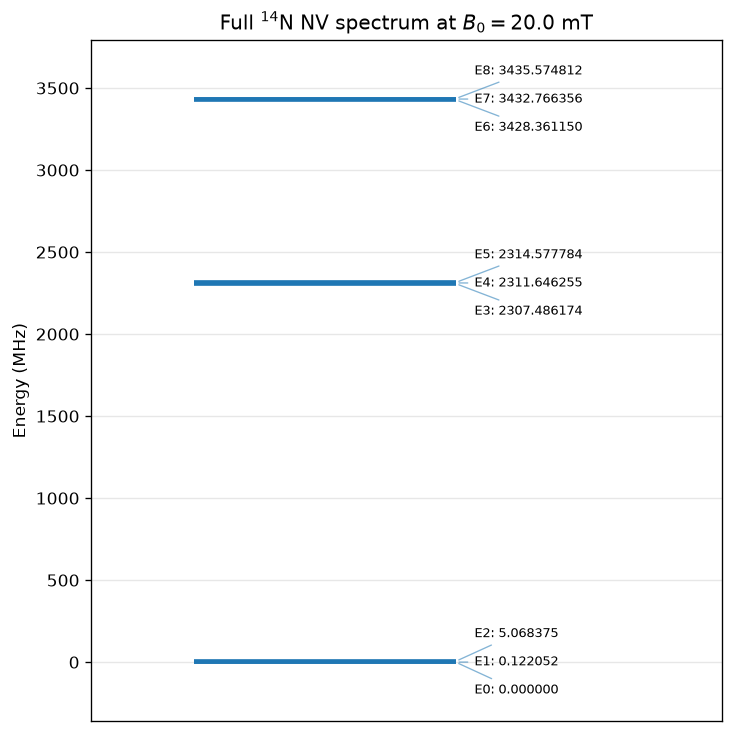

E0: 0.000000000 MHz
E1: 0.122052144 MHz
E2: 5.068374593 MHz
E3: 2307.486174195 MHz
E4: 2311.646254720 MHz
E5: 2314.577783968 MHz
E6: 3428.361149639 MHz
E7: 3432.766356438 MHz
E8: 3435.574811556 MHz


In [30]:
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
plot_energy_level_diagram(
    ax,
    full_energy_levels_mhz,
    labels=[f"E{index}" for index in range(9)],
    title=rf"Full $^{{14}}$N NV spectrum at $B_0={B0_mT:.1f}$ mT",
)
plt.show()

for index, energy in enumerate(full_energy_levels_mhz):
    print(f"E{index}: {energy:.9f} MHz")

## 3. Retain the complete nine-state NV Hilbert space

The $m_s=+1$ manifold is kept in `nv.H0`; no state truncation is performed. The logical construction below still identifies the three predominantly $m_s=0$ states and the three predominantly $m_s=-1$ states, while the remaining $m_s=+1$ triplet stays available to the full laboratory-frame simulation.


In [31]:
# Keep all three electron-spin manifolds in the QuaCCAToo NV object.
retained_energy_levels_mhz = np.asarray(nv.energy_levels, dtype=float).copy()

print("Retained Hamiltonian shape:", nv.H0.shape)
print("Number of retained energy levels:", len(retained_energy_levels_mhz))

assert nv.H0.shape == (9, 9)
assert len(retained_energy_levels_mhz) == 9


Retained Hamiltonian shape: (9, 9)
Number of retained energy levels: 9


## 4. Derive the two three-state manifolds from the NV Hamiltonian

We diagonalize the complete nine-level `nv.H0`, classify its eigenstates by their $m_s=0$, $m_s=-1$, or $m_s=+1$ weight, and then label them by maximum overlap with the product states $|m_s,m_I\rangle$. This retains the small hyperfine mixing present in the physical Hamiltonian rather than assuming exact product eigenstates.

The derived eigenvectors do not exactly match the ideal eigenstates because of this hyperfine mixing in the Hamiltonian. However, the mixing effect is not large enough for maximal mixing, and the ideal eigenstates can still be reversed out of the derived eigenstates.

In [32]:
# Reference product states in the requested (-, 0, +) nuclear ordering.
# QuTiP orders the electron spin-1 basis as m_s=(+1,0,-1), so indices
# 1 and 2 identify the two manifolds used for the tripod construction.
ground_references = tuple(tensor(basis(3, 1), basis(3, index)) for index in (2, 1, 0))
excited_references = tuple(tensor(basis(3, 2), basis(3, index)) for index in (2, 1, 0))
state_names = ("minus", "zero", "plus")

P_ms_zero = tensor(ket2dm(basis(3, 1)), qeye(3))
P_ms_minus = tensor(ket2dm(basis(3, 2)), qeye(3))
P_ms_plus = tensor(ket2dm(basis(3, 0)), qeye(3))
eigenenergies_mhz, eigenstates = nv.H0.eigenstates()

ground_candidates = [state for state in eigenstates if expect(P_ms_zero, state) >= 0.5]
excited_candidates = [state for state in eigenstates if expect(P_ms_minus, state) > 0.5]
plus_candidates = [state for state in eigenstates if expect(P_ms_plus, state) > 0.5]

def order_states_by_reference(candidates, references):
    overlap = np.array([[abs(reference.overlap(state))**2 for state in candidates] for reference in references])
    best_order = max(permutations(range(3)), key=lambda order: sum(overlap[row, order[row]] for row in range(3)))
    return tuple(candidates[index] for index in best_order), overlap[:, best_order]

ground_states, ground_overlap = order_states_by_reference(ground_candidates, ground_references)
bare_excited_states, excited_overlap = order_states_by_reference(excited_candidates, excited_references)
ground_energies_mhz = np.array([float(expect(nv.H0, state)) for state in ground_states])
bare_excited_energies_mhz = np.array([float(expect(nv.H0, state)) for state in bare_excited_states])

print("Ground-state energies in (-, 0, +) order (MHz):", ground_energies_mhz)
print("Bare excited energies in (-, 0, +) order (MHz):", bare_excited_energies_mhz)
print("Assigned ground-state product overlaps:\n", ground_overlap)
print("Assigned excited-state product overlaps:\n", excited_overlap)
print("Number of retained m_s=+1-like eigenstates:", len(plus_candidates))
assert len(ground_states) == len(bare_excited_states) == len(plus_candidates) == 3

Ground-state energies in (-, 0, +) order (MHz): [-4.95160977 -0.00528732 -5.07366192]
Bare excited energies in (-, 0, +) order (MHz): [2302.41251228 2309.50412205 2306.5725928 ]
Assigned ground-state product overlaps:
 [[0.99999864 0.         0.        ]
 [0.         0.99999801 0.        ]
 [0.         0.         0.99999938]]
Assigned excited-state product overlaps:
 [[1.         0.         0.        ]
 [0.         0.99999864 0.        ]
 [0.         0.         0.99999863]]
Number of retained m_s=+1-like eigenstates: 3


## 5. Dress the $m_s=-1$ manifold with two RF tones

A single RF carrier does not resonantly connect all three $m_s=-1$ sublevels. We therefore use one tone for each adjacent transition. In the resonant multi-rotating frame and rotating-wave approximation,

$$H_{\mathrm{dress}}=\frac{\Omega_{\mathrm{RF}}}{2}\,P_eH_{\mathrm{RF}}P_e,$$

with only the driven transition matrix elements retained. Its nondegenerate lowest-quasienergy eigenstate is the isolated ancilla $|e\rangle$; the gap to the nearest other dressed state is $\Delta_{\mathrm{RF}}$. Here "singlet ancilla" means one isolated nondegenerate dressed state, not the NV's optical electronic singlet manifold.

### Ancilla-energy consistency check

If the returned coefficient vector $\mathbf c=(c_-,c_0,c_+)^T$ is the selected dressed eigenstate, then its expectation value must reproduce the selected rotating-frame quasienergy,

$$\langle H_{\rm dressed}\rangle_e
=\mathbf c^\dagger H_{\rm dressed}\mathbf c
=\varepsilon_e.$$

The stronger residual check $\|H_{\rm dressed}\mathbf c-\varepsilon_e\mathbf c\|=0$ verifies that the coefficients form the eigenvector itself, not merely a state with the same expectation value. These are dressed-frame quasienergy checks; they should not be interpreted as the bare laboratory-frame expectation value of `nv.H0`.


Projected RF control matrix in the supplied excited basis:
[[0.         0.99999932 0.        ]
 [0.99999932 0.         1.        ]
 [0.         1.         0.        ]]
Rotating-frame dressed Hamiltonian (MHz):
[[0.         0.74999949 0.        ]
 [0.74999949 0.         0.75      ]
 [0.         0.75       0.        ]]
Dressed quasienergies (MHz): [-1.06065981e+00  8.85606963e-17  1.06065981e+00]
Selected lowest dressed-state coefficients: [-0.49999983  0.70710678 -0.50000017]


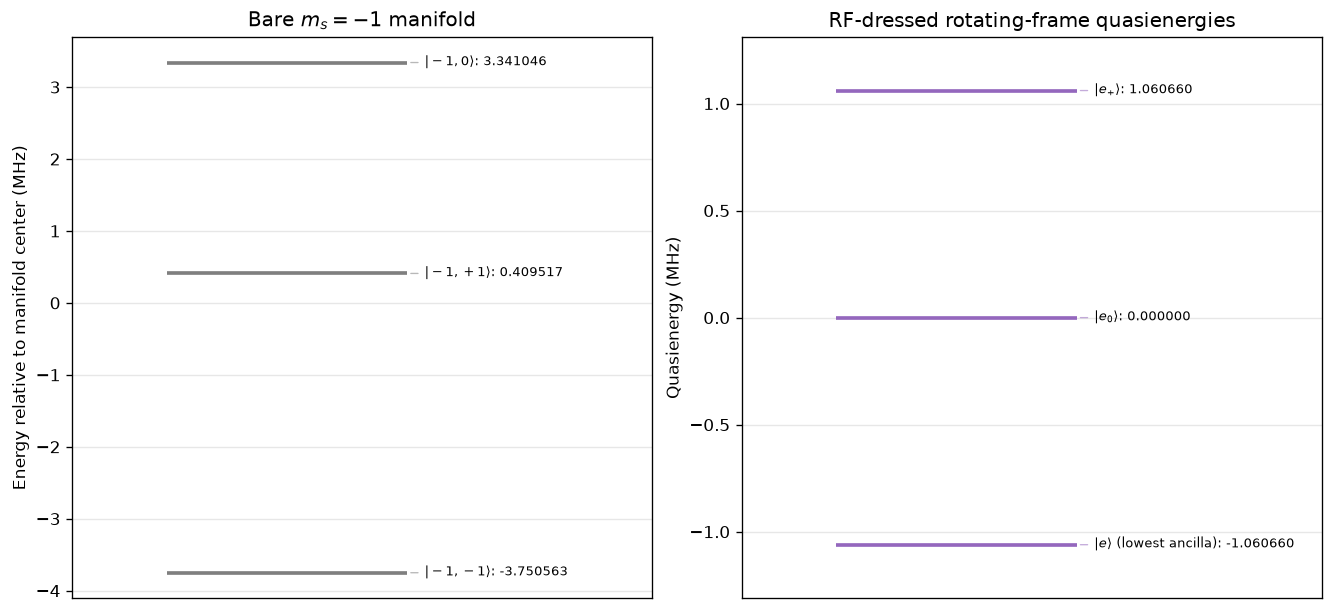

RF carrier frequencies (MHz): [7.09160977 2.93152925]
|e> coefficients in the derived (-, 0, +) basis: [-0.49999983  0.70710678 -0.50000017]
|e> quasienergy (MHz): -1.060659811
|e_0> coefficients in the derived (-, 0, +) basis: [ 7.07107022e-01  2.15105711e-16 -7.07106541e-01]
|e_0> quasienergy (MHz): 0.000000000
|e_+> coefficients in the derived (-, 0, +) basis: [0.49999983 0.70710678 0.50000017]
|e_+> quasienergy (MHz): 1.060659811
Nearest dressed-state separation Delta_RF = 1.060660 MHz
Dressed-state overlap matrix:
 [[ 1.00000000e+00  2.77555756e-16  2.77555756e-17]
 [ 2.77555756e-16  1.00000000e+00 -5.55111512e-17]
 [ 2.77555756e-17 -5.55111512e-17  1.00000000e+00]]
Dressed-projector closure error: 6.254396599051903e-16
Dressed-state quasienergies from expectation values (MHz): [-1.06065981e+00 -2.76908042e-33  1.06065981e+00]
Dressed-state eigenvector residuals (MHz): [2.71947991e-16 2.44739120e-16 1.11022302e-16]


In [33]:
rf_transition_frequencies_mhz = np.array([
    abs(bare_excited_energies_mhz[1] - bare_excited_energies_mhz[0]),
    abs(bare_excited_energies_mhz[2] - bare_excited_energies_mhz[1]),
])

(
    ancilla_coefficients,
    dressed_quasienergies_mhz,
    dressed_eigenvectors,
    projected_rf_matrix,
    H_dressed_mhz,
) = extract_ancilla_coefficients(
    nv,
    bare_excited_states,
    rf_rabi_mhz=RF_RABI_MHZ,
    detunings_mhz=DETUNINGS_MHZ,
    ancilla_branch="lowest",
    return_details=True,
)

# np.linalg.eigh returns the RF-dressed branches in ascending quasienergy.
# Fix each column's arbitrary global phase, then lift all three coefficient
# vectors from the projected basis back into the full nine-state NV Hilbert space.
dressed_state_coefficients = np.asarray(dressed_eigenvectors, dtype=complex).copy()
for dressed_index in range(dressed_state_coefficients.shape[1]):
    coefficients = dressed_state_coefficients[:, dressed_index]
    phase_reference = coefficients[np.argmax(np.abs(coefficients))]
    coefficients *= np.exp(-1j * np.angle(phase_reference))
    dressed_state_coefficients[:, dressed_index] = coefficients / np.linalg.norm(coefficients)

ancilla_index = int(np.argmin(dressed_quasienergies_mhz))
e_zero_index = 1
e_plus_index = int(np.argmax(dressed_quasienergies_mhz))

ancilla_coefficients = dressed_state_coefficients[:, ancilla_index]
e_zero_coefficients = dressed_state_coefficients[:, e_zero_index]
e_plus_coefficients = dressed_state_coefficients[:, e_plus_index]

dressed_excited_states = tuple(
    sum(
        coefficient * bare_state
        for coefficient, bare_state in zip(coefficients, bare_excited_states)
    ).unit()
    for coefficients in dressed_state_coefficients.T
)
excited_state = dressed_excited_states[ancilla_index]
excited_state_zero = dressed_excited_states[e_zero_index]
excited_state_plus = dressed_excited_states[e_plus_index]

# Verify all three states against the same rotating-frame dressed Hamiltonian.
dressed_state_energy_expectations_mhz = np.array([
    float(np.real(np.vdot(coefficients, H_dressed_mhz @ coefficients)))
    for coefficients in dressed_state_coefficients.T
])
dressed_state_residuals_mhz = np.array([
    np.linalg.norm(
        H_dressed_mhz @ dressed_state_coefficients[:, index]
        - dressed_quasienergies_mhz[index] * dressed_state_coefficients[:, index]
    )
    for index in range(3)
])
dressed_excited_overlap_matrix = np.array([
    [state_a.overlap(state_b) for state_b in dressed_excited_states]
    for state_a in dressed_excited_states
])
bare_excited_manifold_projector = sum(ket2dm(state) for state in bare_excited_states)
dressed_excited_manifold_projector = sum(ket2dm(state) for state in dressed_excited_states)
dressed_projector_closure_error = (
    dressed_excited_manifold_projector - bare_excited_manifold_projector
).norm()

ancilla_quasienergy_from_expectation_mhz = dressed_state_energy_expectations_mhz[ancilla_index]
ancilla_quasienergy_from_eigenvalue_mhz = float(dressed_quasienergies_mhz[ancilla_index])
ancilla_eigen_residual_mhz = float(dressed_state_residuals_mhz[ancilla_index])
delta_rf_mhz = float(dressed_quasienergies_mhz[1] - dressed_quasienergies_mhz[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
plot_rf_dressing_comparison(
    axes,
    bare_excited_energies_mhz - np.mean(bare_excited_energies_mhz),
    dressed_quasienergies_mhz,
    bare_labels=[r"$|-1,-1\rangle$", r"$|-1,0\rangle$", r"$|-1,+1\rangle$"],
    dressed_labels=[r"$|e\rangle$ (lowest ancilla)", r"$|e_{0}\rangle$", r"$|e_{+}\rangle$"],
)
plt.show()

print("RF carrier frequencies (MHz):", rf_transition_frequencies_mhz)
for label, coefficients, quasienergy in zip(
    ("e", "e_0", "e_+"),
    dressed_state_coefficients.T,
    dressed_quasienergies_mhz,
):
    print(
        f"|{label}> coefficients in the derived (-, 0, +) basis:",
        np.real_if_close(coefficients),
    )
    print(f"|{label}> quasienergy (MHz): {quasienergy:.9f}")

print(f"Nearest dressed-state separation Delta_RF = {delta_rf_mhz:.6f} MHz")
print("Dressed-state overlap matrix:\n", np.real_if_close(dressed_excited_overlap_matrix))
print("Dressed-projector closure error:", dressed_projector_closure_error)
print(
    "Dressed-state quasienergies from expectation values (MHz):",
    dressed_state_energy_expectations_mhz,
)
print("Dressed-state eigenvector residuals (MHz):", dressed_state_residuals_mhz)

assert ancilla_index == 0
assert e_zero_index == 1
assert e_plus_index == 2
assert delta_rf_mhz > 0.0
assert np.allclose(dressed_excited_overlap_matrix, np.eye(3), atol=1e-12)
assert dressed_projector_closure_error < 1e-12
assert np.allclose(
    dressed_state_energy_expectations_mhz,
    dressed_quasienergies_mhz,
    atol=1e-12,
)
assert np.max(dressed_state_residuals_mhz) < 1e-12


## 5.5 Logical tripod and higher dressed states derived from the Hamiltonian

The three low-energy eigenstates become $|g_-\rangle$, $|g_0\rangle$, and $|g_+\rangle$. Diagonalizing the RF Hamiltonian gives a complete orthonormal basis of the dressed $m_s=-1$ manifold: the lowest branch $|e\rangle$ is the intended tripod ancilla, while the middle and highest branches are denoted $|e_0\rangle$ and $|e_+\rangle$. Their projectors allow the simulations below to distinguish leakage into the two unwanted dressed branches from population retained in the four-state tripod.


In [34]:
g_minus, g_zero, g_plus = ground_states
ground_labels = (r"$P_{g_-}$", r"$P_{g_0}$", r"$P_{g_+}$")

P_g_minus, P_g_zero, P_g_plus = map(ket2dm, ground_states)
P_excited = ket2dm(excited_state)
P_excited_zero = ket2dm(excited_state_zero)
P_excited_plus = ket2dm(excited_state_plus)
P_higher_excited_total = P_excited_zero + P_excited_plus
P_ground_total = P_g_minus + P_g_zero + P_g_plus
P_tripod = P_ground_total + P_excited
P_all_states = qeye(nv.H0.dims[0])

print("Derived logical-state checks:")
for name, state, energy in zip(state_names, ground_states, ground_energies_mhz):
    print(f"  |g_{name}>: <H0> = {energy:.9f} MHz, ms=0 weight = {expect(P_ms_zero, state):.9f}")
for label, coefficients, state in zip(
    ("e", "e_0", "e_+"),
    dressed_state_coefficients.T,
    dressed_excited_states,
):
    print(f"  |{label}> coefficients:", np.real_if_close(coefficients))
    print(f"  |{label}> ms=-1 weight: {expect(P_ms_minus, state):.9f}")

assert np.allclose([[a.overlap(b) for b in ground_states] for a in ground_states], np.eye(3))
assert np.allclose(
    [[a.overlap(b) for b in dressed_excited_states] for a in dressed_excited_states],
    np.eye(3),
    atol=1e-12,
)
assert all(np.isclose(expect(P_ms_minus, state), 1.0, atol=1e-4) for state in dressed_excited_states)
assert (P_excited + P_higher_excited_total - bare_excited_manifold_projector).norm() < 1e-12


Derived logical-state checks:
  |g_minus>: <H0> = -4.951609773 MHz, ms=0 weight = 0.999998639
  |g_zero>: <H0> = -0.005287324 MHz, ms=0 weight = 0.999998009
  |g_plus>: <H0> = -5.073661917 MHz, ms=0 weight = 0.999999382
  |e> coefficients: [-0.49999983  0.70710678 -0.50000017]
  |e> ms=-1 weight: 0.999998977
  |e_0> coefficients: [ 7.07107022e-01  2.15105711e-16 -7.07106541e-01]
  |e_0> ms=-1 weight: 0.999999315
  |e_+> coefficients: [0.49999983 0.70710678 0.50000017]
  |e_+> ms=-1 weight: 0.999998977


## 5.6 Verify the effective tripod Hamiltonian against Equation (3)

The RF-dressed Hamiltonian from Section 5 is used to obtain

$$|e\rangle=\sum_{m\in\{-,0,+\}}c_m|-1,m\rangle.$$

For an approximately nuclear-spin-preserving microwave operator, the projected matrix element is

$$\langle e|H_{\rm MW}|g_m\rangle
\simeq c_m^*\langle-1,m|H_{\rm MW}|g_m\rangle.$$

Thus your proposed relation is correct if $\Omega_m^{(\rm bare)}$ already includes the bare transition matrix element and the programmed tone amplitude:

$$\widetilde\Omega_m^{(\rm projected)}
=c_m^*\Omega_m^{(\rm bare)}.$$

One notational refinement is important. Equation (3) writes a nonnegative amplitude and a separate phase,

$$H(t)=\frac{\hbar}{2}\sum_m
\left[\Omega_m^{(\rm paper)}(t)e^{-i\phi_m^{(\rm paper)}(t)}
|e\rangle\langle g_m|+\mathrm{h.c.}\right].$$

Because $c_m$ and the bare transition matrix element may be complex, `projected_mw_couplings_mhz` below is the full complex projected coupling. Its magnitude becomes $\Omega_m^{(\rm paper)}$, while its phase is combined with the programmed microwave phase. The code constructs the effective matrix once by direct assignment and again from the ket-bra sum in Equation (3), then compares every element.

In [35]:
# Bare transition matrix in the ordered (-, 0, +) manifolds. The diagonal
# entries are the approximately nuclear-spin-preserving tripod transitions.
mw_transition_matrix = np.array([
    [complex(exc.dag() * nv.MW_h1 * ground) for ground in ground_states]
    for exc in bare_excited_states
])
mw_diagonal_elements = np.diag(mw_transition_matrix)

# Project each bare transition onto |e>. This is the detailed version of
# Omega_projected_m = c_m^* Omega_bare_m: the bare coupling also contains the
# physical MW matrix element supplied by the full QuaCCAToo NV Hamiltonian.
effective_leg_elements = np.conjugate(ancilla_coefficients) * mw_diagonal_elements

# Preserve the existing pulse prescription: compensate unequal projected
# matrix-element magnitudes with relative tone weights and retain its phases.
raw_tone_weights = 1.0 / np.maximum(np.abs(effective_leg_elements), 1e-12)
mw_tone_weights = raw_tone_weights / np.max(raw_tone_weights)
mw_tone_phases = -np.angle(effective_leg_elements)

# Complex projected couplings before and after the programmed MW phase.
Omega_bare_mhz = MW_RABI_MHZ * mw_tone_weights * mw_diagonal_elements
projected_mw_couplings_mhz = np.conjugate(ancilla_coefficients) * Omega_bare_mhz
tripod_complex_coefficients_mhz = (
    projected_mw_couplings_mhz * np.exp(-1j * mw_tone_phases)
)

# Translate the complex coefficients into the paper's amplitude/phase notation:
# K_m = Omega_m^(paper) exp[-i phi_m^(paper)].
Omega_paper_mhz = np.abs(tripod_complex_coefficients_mhz)
phi_paper_rad = -np.angle(tripod_complex_coefficients_mhz)

# Direct matrix representation in [|g_->, |g_0>, |g_+>, |e>].
H_tripod_from_nv_mhz = np.zeros((4, 4), dtype=complex)
for m, coefficient in enumerate(tripod_complex_coefficients_mhz):
    H_tripod_from_nv_mhz[3, m] = 0.5 * coefficient
    H_tripod_from_nv_mhz[m, 3] = 0.5 * np.conjugate(coefficient)

# Independent reconstruction of paper Eq. (3) from ket-bra outer products.
effective_basis = np.eye(4, dtype=complex)
g_basis_vectors = effective_basis[:3]
e_basis_vector = effective_basis[3]
H_equation3_mhz = np.zeros((4, 4), dtype=complex)
for m in range(3):
    ket_e_bra_gm = np.outer(e_basis_vector, np.conjugate(g_basis_vectors[m]))
    forward_term = (
        Omega_paper_mhz[m]
        * np.exp(-1j * phi_paper_rad[m])
        * ket_e_bra_gm
    )
    H_equation3_mhz += 0.5 * (forward_term + forward_term.conjugate().T)

equation3_difference_mhz = H_tripod_from_nv_mhz - H_equation3_mhz

print("Bare MW transition matrix in (-, 0, +) order:\n", mw_transition_matrix)
print("\nProjected complex MW couplings (MHz):", projected_mw_couplings_mhz)
print("Paper Omega_m amplitudes (MHz):", Omega_paper_mhz)
print("Paper phi_m phases (rad):", phi_paper_rad)
print("\nTripod Hamiltonian derived from the full NV model (MHz):\n", H_tripod_from_nv_mhz)
print("\nTripod Hamiltonian reconstructed from Eq. (3) (MHz):\n", H_equation3_mhz)
print("\nMaximum elementwise difference (MHz):", np.max(np.abs(equation3_difference_mhz)))

# Verify the factor 1/2, phase convention, Hermitian conjugates, basis order,
# and the absence of direct ground-to-ground or ancilla diagonal couplings.
assert np.allclose(H_tripod_from_nv_mhz, H_equation3_mhz, atol=1e-14)
assert np.allclose(H_equation3_mhz, H_equation3_mhz.conjugate().T)
assert np.allclose(H_equation3_mhz[:3, :3], 0.0)
assert np.isclose(H_equation3_mhz[3, 3], 0.0)

print("\nPASS: the projected full-NV microwave couplings reproduce paper Equation (3).")


Bare MW transition matrix in (-, 0, +) order:
 [[ 9.99999320e-01+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  9.99997405e-01+0.j  0.00000000e+00+0.j]
 [-4.18463760e-06+0.j  0.00000000e+00+0.j  9.99998086e-01+0.j]]

Projected complex MW couplings (MHz): [-0.03999994+4.89857949e-18j  0.03999994-4.89857949e-18j
 -0.03999994+4.89857949e-18j]
Paper Omega_m amplitudes (MHz): [0.03999994 0.03999994 0.03999994]
Paper phi_m phases (rad): [2.4492936e-16 2.4492936e-16 2.4492936e-16]

Tripod Hamiltonian derived from the full NV model (MHz):
 [[0.        +0.00000000e+00j 0.        +0.00000000e+00j
  0.        +0.00000000e+00j 0.01999997+4.89857949e-18j]
 [0.        +0.00000000e+00j 0.        +0.00000000e+00j
  0.        +0.00000000e+00j 0.01999997+4.89857949e-18j]
 [0.        +0.00000000e+00j 0.        +0.00000000e+00j
  0.        +0.00000000e+00j 0.01999997+4.89857949e-18j]
 [0.01999997-4.89857949e-18j 0.01999997-4.89857949e-18j
  0.01999997-4.89857949e-18j 0.        +0.0000

## 6. Continuous RF dressing followed by microwave pumping

The RF envelope ramps on first and remains on throughout the sequence. After the dressed basis is established, three phase-coherent microwave tones begin. Their carrier frequencies address the three derived ground-to-excited lines, and their amplitudes compensate the MW matrix elements and ancilla coefficients so that the effective tripod legs are approximately balanced. The full nine-state laboratory Hamiltonian is then evolved by QuaCCAToo.

The calculation is shown in three stages: the applied control amplitudes, the duration-swept `Rabi` experiment, and an independent stepped `PulsedSim` evolution using the same full nine-state system, control Hamiltonians, carrier-resolved pulse functions, and solver tolerances.


### 6.1 RF and three-tone microwave controls

The plot shows slowly varying drive-envelope amplitudes so the timing and relative tone strengths remain readable. The GHz/MHz carrier oscillations are retained in `rf_dressing_pulse` and `microwave_pulse` during simulation but are intentionally not drawn over the full eight-microsecond window.

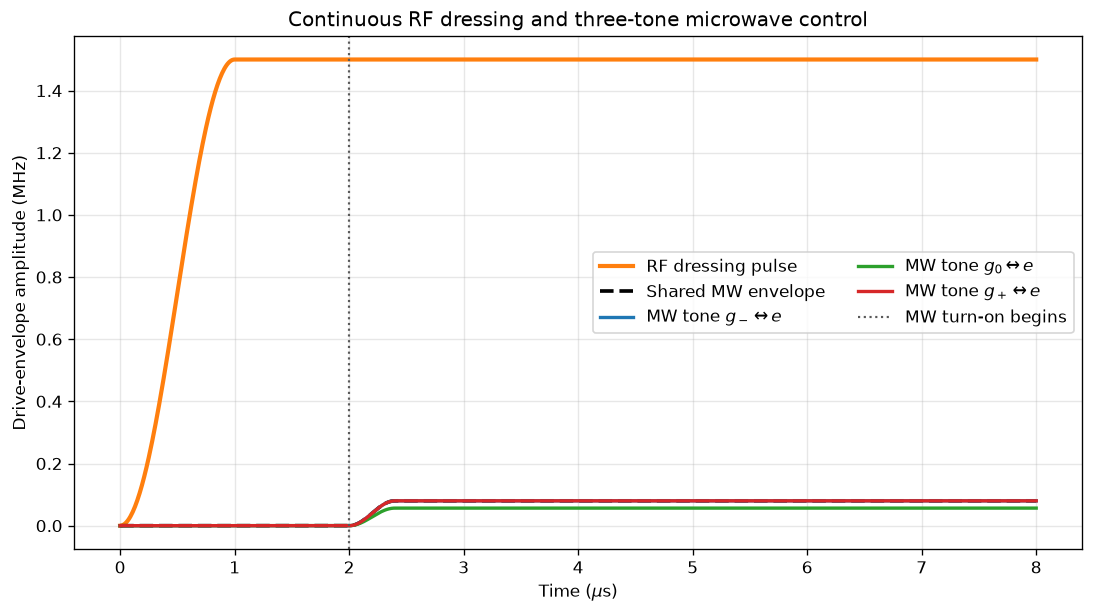

RF tones (MHz): [7.09160977 2.93152925]
MW tones (MHz): [2306.30346224 2308.44874956 2310.58559491]
MW relative tone weights: [0.99999945 0.7071075  1.        ]
MW tone phases (rad): [-3.14159265e+00  1.22464680e-16 -3.14159265e+00]


In [36]:
pulse_times_us = np.linspace(0.0, TOTAL_TIME_US, 801)

def solver_to_physical_time_us(t):
    return np.asarray(t) / (2.0 * np.pi)

def sin2_turn_on(time_us, start_us, ramp_us):
    x = np.clip((np.asarray(time_us) - start_us) / ramp_us, 0.0, 1.0)
    return np.sin(0.5 * np.pi * x)**2

def rf_envelope(time_us):
    return sin2_turn_on(time_us, 0.0, RF_RAMP_TIME_US)

def mw_envelope(time_us):
    return sin2_turn_on(time_us, MW_START_TIME_US, MW_RAMP_TIME_US)

def rf_dressing_pulse(t, **kwargs):
    time_us = solver_to_physical_time_us(t)
    carriers = sum(np.cos(frequency * t) for frequency in rf_transition_frequencies_mhz)
    return rf_envelope(time_us) * carriers

# Reuse the microwave matrix elements, balancing weights, and phases
# that were explicitly verified against Equation (3) above.
ancilla_shift_mhz = float(dressed_quasienergies_mhz[ancilla_index])
mw_transition_frequencies_mhz = np.abs(bare_excited_energies_mhz - ground_energies_mhz) + ancilla_shift_mhz

def microwave_pulse(t, **kwargs):
    time_us = solver_to_physical_time_us(t)
    carriers = sum(
        weight * np.cos(frequency * t + phase)
        for weight, frequency, phase in zip(
            mw_tone_weights, mw_transition_frequencies_mhz, mw_tone_phases
        )
    )
    return mw_envelope(time_us) * carriers

# Display the slowly varying drive amplitudes. The laboratory simulation below
# still uses the carrier-resolved rf_dressing_pulse and microwave_pulse functions.
rf_drive_envelope_mhz = RF_RABI_MHZ * rf_envelope(pulse_times_us)
mw_shared_envelope_mhz = MW_RABI_MHZ * mw_envelope(pulse_times_us)
mw_tone_envelopes_mhz = np.array([
    MW_RABI_MHZ * weight * mw_envelope(pulse_times_us)
    for weight in mw_tone_weights
])

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
ax.plot(
    pulse_times_us, rf_drive_envelope_mhz,
    lw=2.5, color="tab:orange", label="RF dressing pulse",
)
ax.plot(
    pulse_times_us, mw_shared_envelope_mhz,
    lw=2.2, color="black", ls="--", label="Shared MW envelope",
)
for tone_envelope, label, color in zip(
    mw_tone_envelopes_mhz,
    (r"MW tone $g_-\leftrightarrow e$", r"MW tone $g_0\leftrightarrow e$", r"MW tone $g_+\leftrightarrow e$"),
    ("tab:blue", "tab:green", "tab:red"),
):
    ax.plot(pulse_times_us, tone_envelope, lw=2.0, color=color, label=label)
ax.axvline(MW_START_TIME_US, color="0.35", ls=":", lw=1.3, label="MW turn-on begins")
ax.set(
    xlabel=r"Time ($\mu$s)",
    ylabel="Drive-envelope amplitude (MHz)",
    title="Continuous RF dressing and three-tone microwave control",
)
ax.legend(ncol=2)
plt.show()

print("RF tones (MHz):", rf_transition_frequencies_mhz)
print("MW tones (MHz):", mw_transition_frequencies_mhz)
print("MW relative tone weights:", mw_tone_weights)
print("MW tone phases (rad):", mw_tone_phases)

#### Interpreting the drive-amplitude plot

The RF dressing pulse ramps on first and remains at constant amplitude, establishing the dressed $m_s=-1$ basis before microwave pumping begins. The dashed black line is the shared MW turn-on envelope. The three colored MW traces include their independently calibrated tone weights; their unequal bare amplitudes compensate the ancilla coefficients and transition matrix elements so that the projected tripod couplings are balanced.

### 6.2 QuaCCAToo `Rabi` duration sweep

`Rabi` integrates the complete carrier-resolved Hamiltonian once over `pulse_times_us`. Its stored states provide the population at every pulse duration, producing the reference oscillation curves below.

Maximum normalization error: 6.661e-16
Maximum selected ancilla population: 0.303406
Minimum total ground population: 0.656614



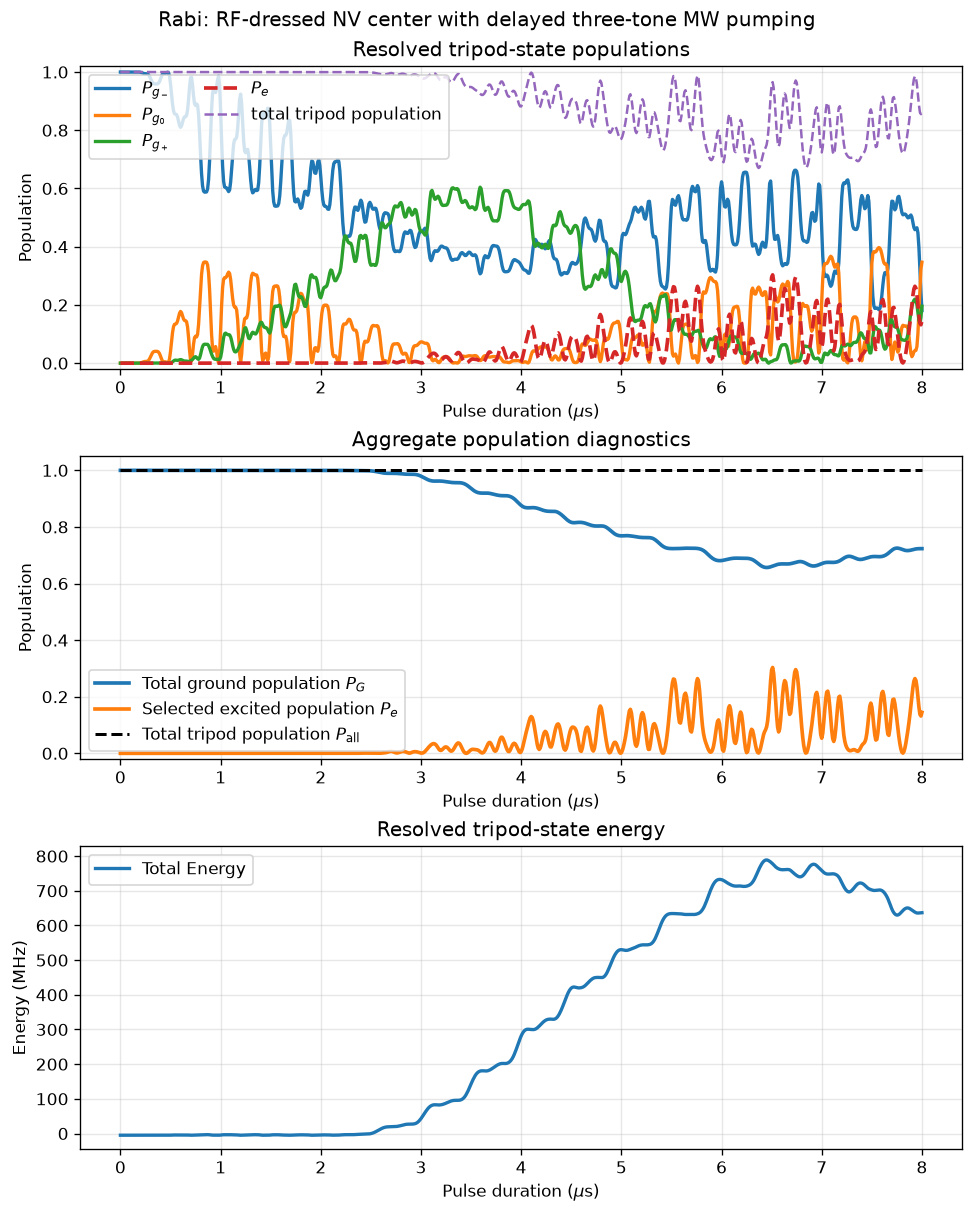

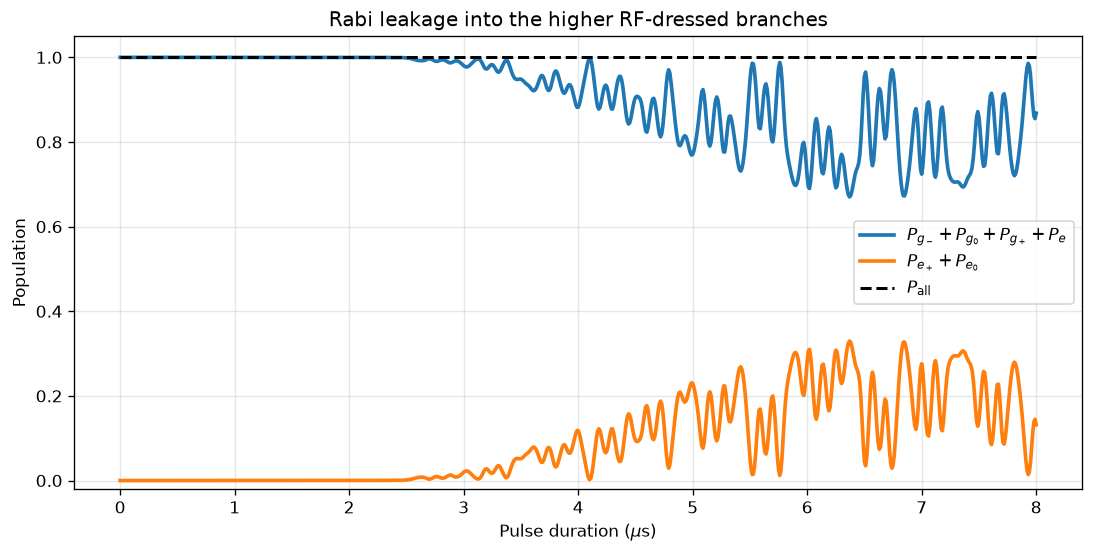

Maximum normalization error: 6.661e-16
Maximum dressed-ancilla population: 0.303406
Maximum higher-dressed leakage: 0.329711


In [37]:
nv.rho0 = g_minus
nv.observable = [
    P_g_minus, P_g_zero, P_g_plus, P_excited,
    P_excited_zero, P_excited_plus,
    P_ground_total, P_all_states, nv.H0,
]

dressed_nv_rabi = Rabi(
    pulse_duration=pulse_times_us,
    system=nv,
    h1=[RF_RABI_MHZ * nv.RF_h1, MW_RABI_MHZ * nv.MW_h1],
    pulse_shape=[rf_dressing_pulse, microwave_pulse],
    options={"nsteps": 500000, "atol": 1e-9, "rtol": 1e-7},
)
dressed_nv_rabi.run()

rabi_results = [np.asarray(result) for result in dressed_nv_rabi.results]
rabi_population_indices = (0, 1, 2, 3, 6, 7)
rabi_population_results = [rabi_results[index] for index in rabi_population_indices]
rabi_e_zero_population = rabi_results[4]
rabi_e_plus_population = rabi_results[5]
rabi_higher_dressed_population = rabi_e_zero_population + rabi_e_plus_population
rabi_tripod_population = rabi_results[6] + rabi_results[3]
rabi_total_energy_mhz = rabi_results[8]

fig, axes = plot_rabi_diagnostics(
    dressed_nv_rabi.variable,
    rabi_population_results,
    ground_labels,
    rabi_total_energy_mhz,
)
fig.suptitle("Rabi: RF-dressed NV center with delayed three-tone MW pumping")
plt.show()

fig_leakage, ax_leakage = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
plot_tripod_leakage(
    ax_leakage,
    dressed_nv_rabi.variable,
    rabi_tripod_population,
    rabi_higher_dressed_population,
    rabi_results[7],
    title="Rabi leakage into the higher RF-dressed branches",
)
plt.show()

P_all_t = rabi_population_results[5]
print(f"Maximum normalization error: {np.max(np.abs(P_all_t - 1.0)):.3e}")
print(f"Maximum dressed-ancilla population: {np.max(rabi_population_results[3]):.6f}")
print(f"Maximum higher-dressed leakage: {np.max(rabi_higher_dressed_population):.6f}")

#### Interpreting the Rabi leakage plot

The intended tripod population includes all three $m_s=0$ ground states and the selected lowest dressed ancilla $|e\rangle$. Its loss is compared directly with population accumulated in the two unwanted RF-dressed branches $|e_0\rangle$ and $|e_+\rangle$. The all-state trace remains one. Any residual gap between the first two curves and $P_{\rm all}$ represents the three remaining $m_s=+1$-like states retained by the full model.


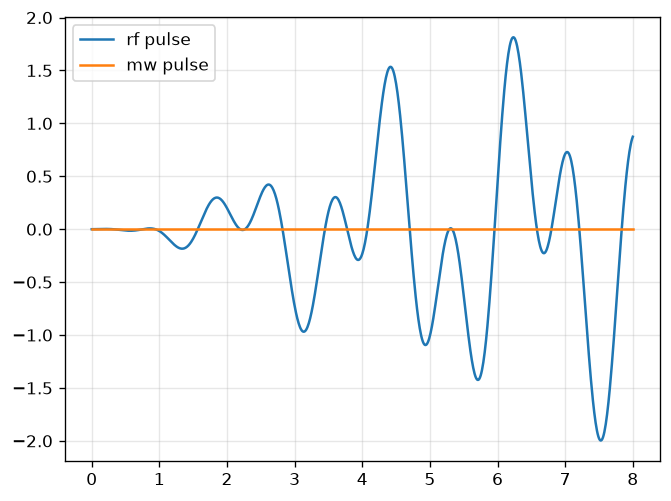

In [38]:
t = np.linspace(0, 8, 801)
rf_pulse_plot = rf_dressing_pulse(t)
mw_pulse_plot = microwave_pulse(t)

plt.plot(t, rf_pulse_plot, label='rf pulse')
plt.plot(t, mw_pulse_plot, label='mw pulse')
plt.legend()

### 6.3 `PulsedSim` population comparison

`PulsedSim.add_pulse` returns the state at the end of a pulse segment. To obtain a trajectory without changing QuaCCAToo internals, the same eight-microsecond pulse is divided into consecutive reporting segments. The state is carried continuously from one segment to the next, and no projective measurements are made.

The comparison uses the same `nv.H0`, initial state, observables, RF/MW control operators, carrier frequencies, envelopes, and solver tolerances as the `Rabi` calculation. Restarting the carrier-resolved integrator at reporting boundaries introduces a small numerical discrepancy, which is plotted explicitly below.


In [39]:
# Use one sequential PulsedSim experiment with forty reporting segments.
pulsedsim_times_us = np.linspace(0.0, TOTAL_TIME_US, 801)
pulsedsim_observable_results = np.empty((9, len(pulsedsim_times_us)), dtype=float)

nv.rho0 = g_minus
dressed_nv_pulsedsim = PulsedSim(nv)
population_observables = [
    P_g_minus, P_g_zero, P_g_plus, P_excited,
    P_excited_zero, P_excited_plus,
    P_ground_total, P_all_states, nv.H0,
]
pulsedsim_observable_results[:, 0] = [
    float(np.real(expect(observable, dressed_nv_pulsedsim.rho)))
    for observable in population_observables
]

for time_index in range(1, len(pulsedsim_times_us)):
    segment_duration_us = float(
        pulsedsim_times_us[time_index] - pulsedsim_times_us[time_index - 1]
    )
    dressed_nv_pulsedsim.add_pulse(
        duration=segment_duration_us,
        h1=[RF_RABI_MHZ * nv.RF_h1, MW_RABI_MHZ * nv.MW_h1],
        pulse_shape=[rf_dressing_pulse, microwave_pulse],
        pulse_params={},
        time_steps=4,
        options={"nsteps": 500000, "atol": 1e-9, "rtol": 1e-7},
    )
    pulsedsim_observable_results[:, time_index] = [
        float(np.real(expect(observable, dressed_nv_pulsedsim.rho)))
        for observable in population_observables
    ]

pulsedsim_population_indices = (0, 1, 2, 3, 6, 7)
pulsedsim_population_results = pulsedsim_observable_results[list(pulsedsim_population_indices)]
pulsedsim_e_zero_population = pulsedsim_observable_results[4]
pulsedsim_e_plus_population = pulsedsim_observable_results[5]
pulsedsim_higher_dressed_population = (
    pulsedsim_e_zero_population + pulsedsim_e_plus_population
)
pulsedsim_tripod_population = (
    pulsedsim_observable_results[6] + pulsedsim_observable_results[3]
)
pulsedsim_total_energy_mhz = pulsedsim_observable_results[8]

# Sample the dense Rabi trajectories at the PulsedSim reporting times.
rabi_observables_at_pulsedsim_times = np.vstack([
    np.interp(pulsedsim_times_us, dressed_nv_rabi.variable, observable_result)
    for observable_result in rabi_results
])
population_difference = (
    pulsedsim_population_results
    - rabi_observables_at_pulsedsim_times[list(rabi_population_indices)]
)
energy_difference_mhz = (
    pulsedsim_total_energy_mhz - rabi_observables_at_pulsedsim_times[8]
)
max_rabi_pulsedsim_difference = float(np.max(np.abs(population_difference)))

print("Maximum |PulsedSim - Rabi| population difference:", max_rabi_pulsedsim_difference)
print(
    "Maximum Rabi ancilla population on the PulsedSim grid:",
    np.max(rabi_observables_at_pulsedsim_times[3]),
)
print(
    "Maximum PulsedSim ancilla population on the same grid:",
    np.max(pulsedsim_population_results[3]),
)
print(
    "PulsedSim maximum normalization error:",
    np.max(np.abs(pulsedsim_population_results[5] - 1.0)),
)
print(
    "Maximum |PulsedSim - Rabi| energy difference (MHz):",
    np.max(np.abs(energy_difference_mhz)),
)

assert np.allclose(pulsedsim_population_results[5], 1.0, atol=1e-6)
assert max_rabi_pulsedsim_difference < 2e-2


Maximum |PulsedSim - Rabi| population difference: 0.014888161376165665
Maximum Rabi ancilla population on the PulsedSim grid: 0.3034055638840071
Maximum PulsedSim ancilla population on the same grid: 0.30986752985340527
PulsedSim maximum normalization error: 6.661338147750939e-16
Maximum |PulsedSim - Rabi| energy difference (MHz): 21.63815453401969


### 6.4 Standalone `PulsedSim` population result

This figure shows the population trajectory returned by the segmented `PulsedSim` evolution on its own, before overlaying it with the denser `Rabi` result.


Maximum normalization error: 6.661e-16
Maximum selected ancilla population: 0.309868
Minimum total ground population: 0.650222



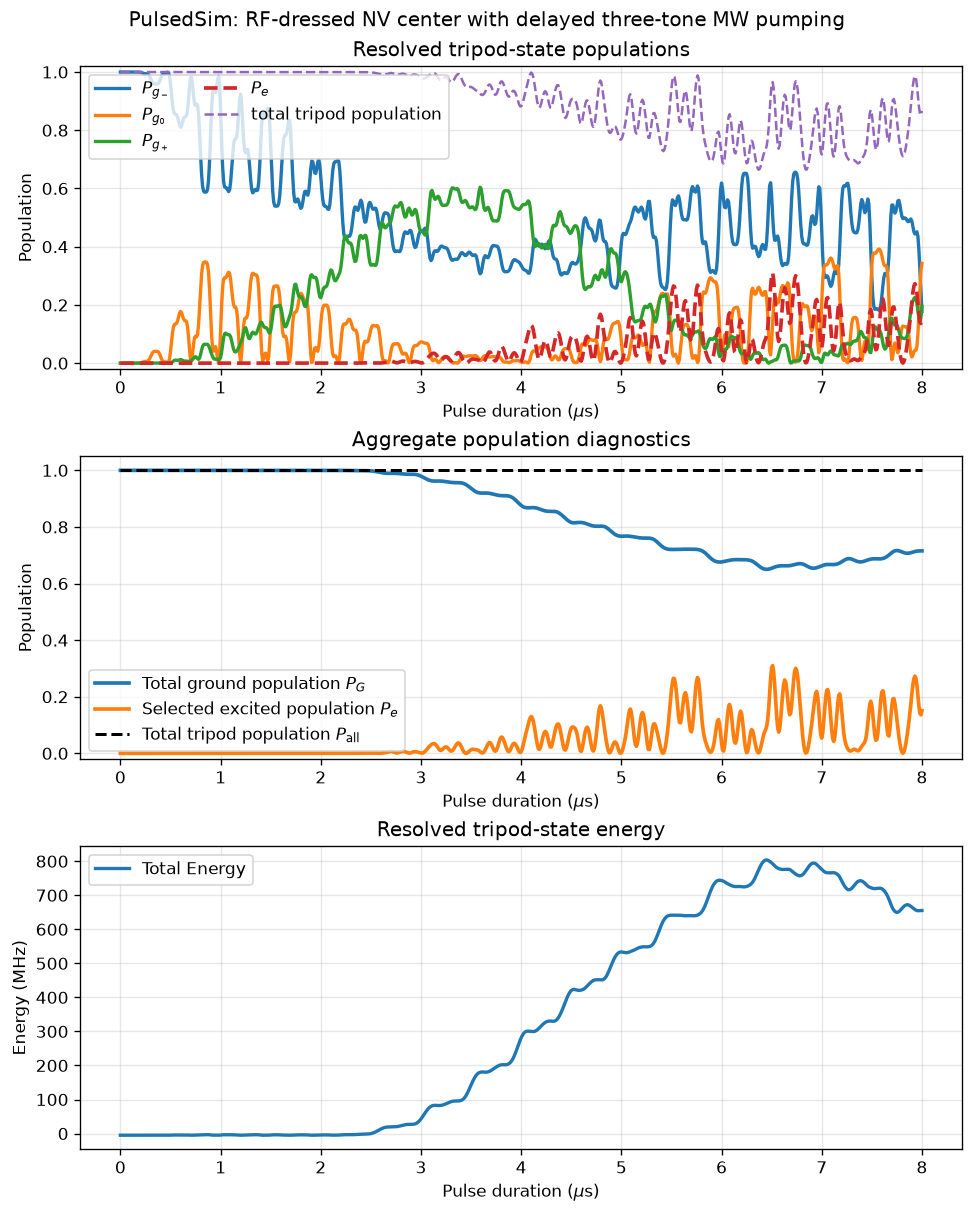

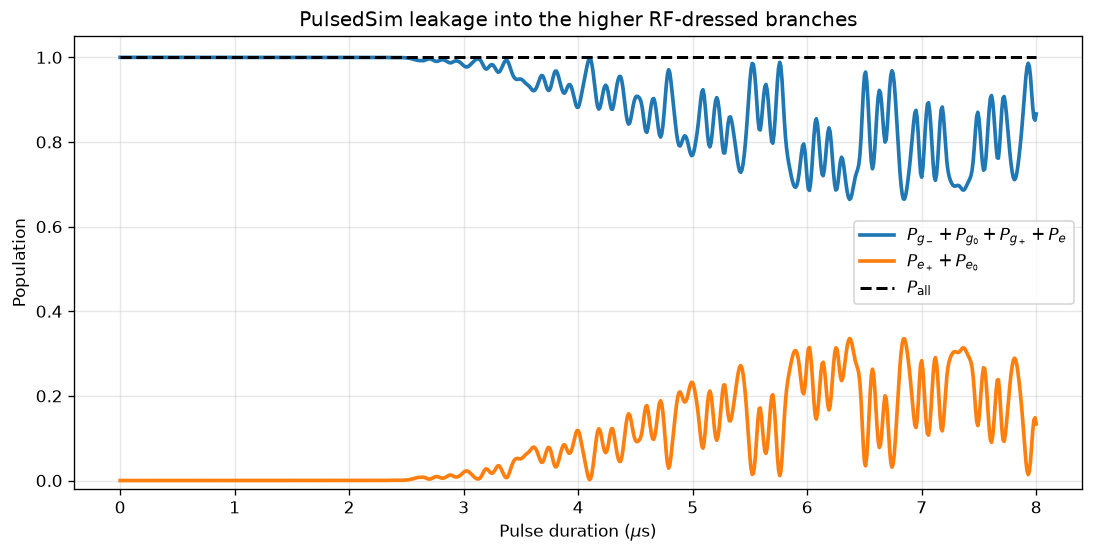

Maximum PulsedSim normalization error: 6.661e-16
Maximum PulsedSim dressed-ancilla population: 0.309868
Maximum PulsedSim higher-dressed leakage: 0.335650


In [40]:
fig, axes = plot_rabi_diagnostics(
    pulsedsim_times_us,
    pulsedsim_population_results,
    ground_labels,
    pulsedsim_total_energy_mhz,
)
fig.suptitle("PulsedSim: RF-dressed NV center with delayed three-tone MW pumping")
plt.show()

fig_leakage, ax_leakage = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
plot_tripod_leakage(
    ax_leakage,
    pulsedsim_times_us,
    pulsedsim_tripod_population,
    pulsedsim_higher_dressed_population,
    pulsedsim_population_results[5],
    title="PulsedSim leakage into the higher RF-dressed branches",
)
plt.show()

print(
    f"Maximum PulsedSim normalization error: "
    f"{np.max(np.abs(pulsedsim_population_results[5] - 1.0)):.3e}"
)
print(
    f"Maximum PulsedSim dressed-ancilla population: "
    f"{np.max(pulsedsim_population_results[3]):.6f}"
)
print(
    f"Maximum PulsedSim higher-dressed leakage: "
    f"{np.max(pulsedsim_higher_dressed_population):.6f}"
)


#### Interpreting the `PulsedSim` populations

The initial state is $|g_-\rangle$, so the RF field alone does not move population before the microwave envelope begins: it dresses the $m_s=-1$ manifold while the state remains in $m_s=0$. Once the three microwave tones turn on, population oscillates through the selected dressed ancilla and can return into all three tripod ground states. The all-state trace remains one; any difference between the summed tripod population and one represents occupation outside the four-state tripod subspace, not loss of normalization.

In the additional leakage panel, the first curve is the complete intended four-state tripod population, while the second is the combined population of $|e_0\rangle$ and $|e_+\rangle$. The gap between their sum and $P_{\rm all}$ can only occupy the remaining three $m_s=+1$-like states of the full nine-level model.


### 6.5 Direct `Rabi`–`PulsedSim` comparison

The upper panel overlays the optimized continuous `Rabi` trajectory with the endpoints obtained from `PulsedSim`. The lower panel isolates the absolute numerical difference for each tripod state.


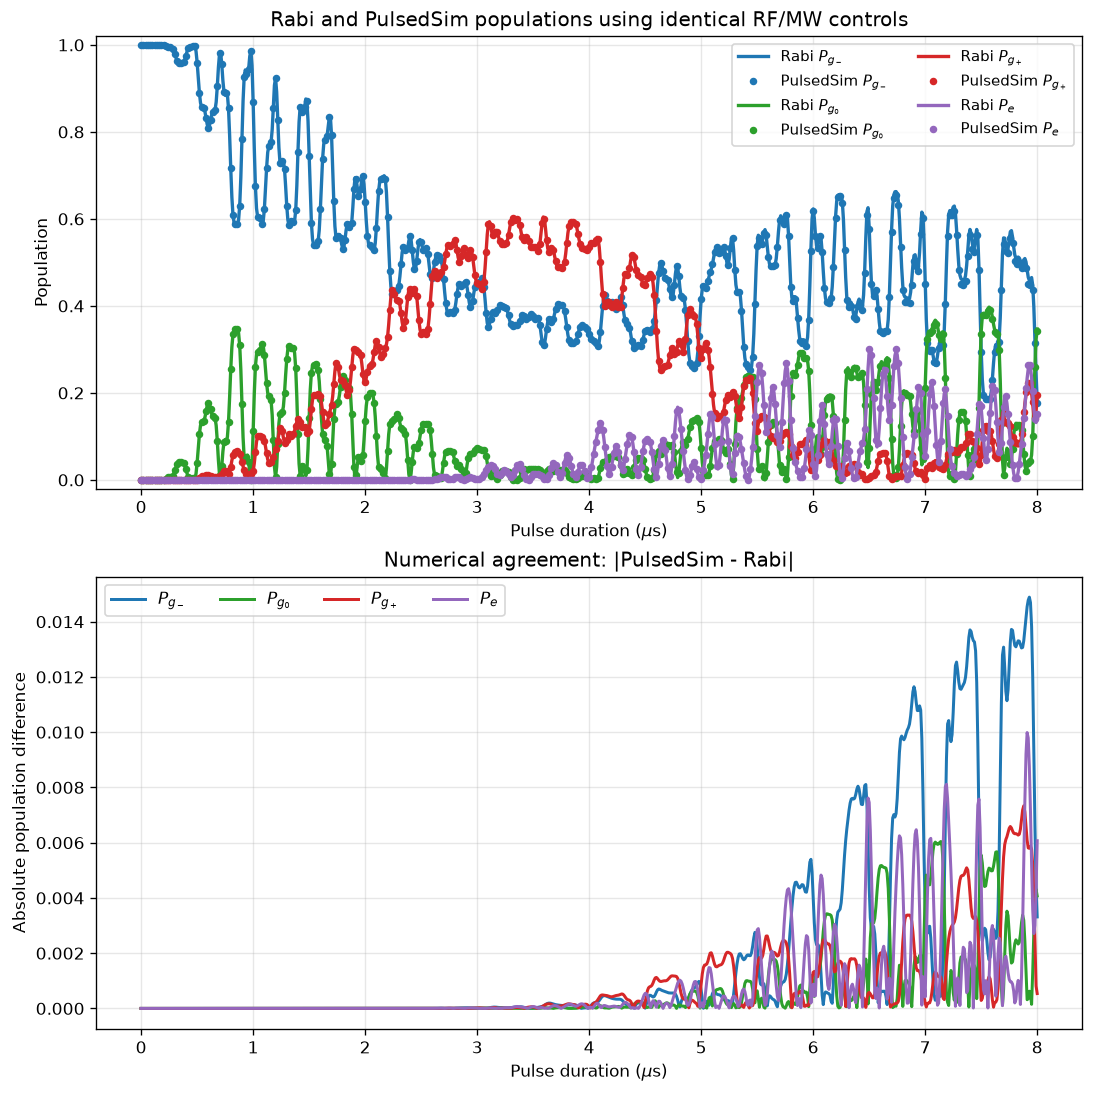

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(9, 9), constrained_layout=True)
comparison_labels = (r"$P_{g_-}$", r"$P_{g_0}$", r"$P_{g_+}$", r"$P_e$")
comparison_colors = ("tab:blue", "tab:green", "tab:red", "tab:purple")

for state_index, (label, color) in enumerate(zip(comparison_labels, comparison_colors)):
    axes[0].plot(
        dressed_nv_rabi.variable,
        rabi_population_results[state_index],
        color=color,
        lw=2,
        label=f"Rabi {label}",
    )
    axes[0].plot(
        pulsedsim_times_us,
        pulsedsim_population_results[state_index],
        color=color,
        marker="o",
        ms=3.5,
        ls="none",
        markevery=2,
        label=f"PulsedSim {label}",
    )

axes[0].set(
    xlabel=r"Pulse duration ($\mu$s)",
    ylabel="Population",
    ylim=(-0.02, 1.02),
    title="Rabi and PulsedSim populations using identical RF/MW controls",
)
axes[0].legend(ncol=2, fontsize=9)

for state_index, (label, color) in enumerate(zip(comparison_labels, comparison_colors)):
    axes[1].plot(
        pulsedsim_times_us,
        np.abs(population_difference[state_index]),
        color=color,
        lw=1.8,
        label=label,
    )
axes[1].set(
    xlabel=r"Pulse duration ($\mu$s)",
    ylabel="Absolute population difference",
    title="Numerical agreement: |PulsedSim - Rabi|",
)
axes[1].legend(ncol=4)
plt.show()


## 7. Four-pulse loop-order experiment

### What this section implements

Each chronological ordering is one QuaCCAToo `PulsedSim` experiment containing exactly four simultaneous physical controls:

1. one RF dressing pulse acting inside the $m_s=-1$ manifold;
2. one MW$_-$ pulse coupling $|g_-\rangle$ to its bare $m_s=-1$ state;
3. one MW$_0$ pulse coupling $|g_0\rangle$ to its bare $m_s=-1$ state;
4. one MW$_+$ pulse coupling $|g_+\rangle$ to its bare $m_s=-1$ state.

There are no separate preparation, loop, or ramp-down pulse objects. Instead, the four pulse functions cover the complete $182\,\mu\mathrm{s}$ experiment and return the appropriate value at every time. This is highlighted by the `FOUR_PHYSICAL_PULSE_NAMES` tuple and by explicit assertions below.

### Loop ordering and amplitude changes

For chronological order `("C1", "C2")`, the MW$_-$ complex envelope is changed during the first loop and the MW$_+$ envelope is changed during the second. Reversing the tuple reverses those two operations. MW$_0$ remains at its nonzero plateau throughout both loops, and all three MW magnitudes remain nonzero from the end of MW turn-on until MW ramp-down begins.

The paper's Equations (8)-(10) define $C_1$ and $C_2$ as phase windings with fixed MW magnitudes. To retain that physics while also making the requested amplitude changes visible, the active MW tone executes both:

$$
|A_m(t)|=A_m^{(0)}\left[1+d\sin^2\!\left(\frac{\pi\tau}{T}\right)\right],
\qquad
\phi_m(t)=2\pi\sin^2\!\left(\frac{\pi\tau}{2T}\right).
$$

Here $d$ is the editable `mw_loop_amplitude_bump_depth`. Setting $d=0$ recovers the paper's fixed-amplitude phase loops exactly. The magnitude bump returns to its starting value at both ends of each loop, while the phase completes one full $2\pi$ winding.

### Complete timing schedule

| Time interval | RF | Three MW pulses | Ordered operation |
|---|---|---|---|
| $0$-$4\,\mu\mathrm{s}$ | Smooth ramp on | Zero | Establish RF dressing |
| $4$-$6\,\mu\mathrm{s}$ | Plateau | Zero | RF settling interval |
| $6$-$12\,\mu\mathrm{s}$ | Plateau | All three ramp on | Open the tripod gap |
| $12$-$92\,\mu\mathrm{s}$ | Plateau | All nonzero | First requested loop |
| $92$-$172\,\mu\mathrm{s}$ | Plateau | All nonzero | Second requested loop |
| $172$-$178\,\mu\mathrm{s}$ | Plateau | All three ramp down | Close the tripod gap |
| $178$-$182\,\mu\mathrm{s}$ | Smooth ramp down | Zero | Remove RF dressing |

In [42]:
# =============================================================================
# 7.1 Editable timing, phase, and amplitude parameters
# =============================================================================
rf_loop_ramp_us = 4.0
rf_settle_us = 2.0
mw_loop_ramp_us = 6.0
berry_loop_duration_us = 80.0
loop_reporting_step_us = 0.5

# The active MW tone rises smoothly above its nonzero plateau during its loop.
# Set this to 0.0 for the paper's fixed-amplitude Equations (8)-(10).
mw_loop_amplitude_bump_depth = 0.25

t_rf_ramp_start_us = 0.0
t_rf_on_us = t_rf_ramp_start_us + rf_loop_ramp_us
t_mw_ramp_start_us = t_rf_on_us + rf_settle_us
t_loop_1_start_us = t_mw_ramp_start_us + mw_loop_ramp_us
t_loop_2_start_us = t_loop_1_start_us + berry_loop_duration_us
t_mw_ramp_down_start_us = t_loop_2_start_us + berry_loop_duration_us
t_mw_zero_us = t_mw_ramp_down_start_us + mw_loop_ramp_us
t_rf_ramp_down_start_us = t_mw_zero_us
t_rf_zero_us = t_rf_ramp_down_start_us + rf_loop_ramp_us
loop_sequence_duration_us = t_rf_zero_us


def sin2_ramp_fraction(time_us, start_us, duration_us):
    """Evaluate a smooth zero-to-one ramp with zero endpoint slopes.

    Parameters
    ----------
    time_us : float or numpy.ndarray
        Absolute physical time in microseconds.
    start_us : float
        Time at which the ramp begins.
    duration_us : float
        Positive ramp duration in microseconds.

    Returns
    -------
    float or numpy.ndarray
        Dimensionless amplitude fraction in the closed interval [0, 1].
    """
    scaled_time = np.clip((np.asarray(time_us) - start_us) / duration_us, 0.0, 1.0)
    return np.sin(0.5 * np.pi * scaled_time)**2


def rf_loop_envelope(time_us):
    """Return the dimensionless envelope of the one RF dressing pulse.

    Parameters
    ----------
    time_us : float or numpy.ndarray
        Absolute physical time in microseconds.

    Returns
    -------
    float or numpy.ndarray
        RF amplitude fraction: ramp on, plateau through both MW loops, then
        ramp to zero only after all three MW pulses have reached zero.
    """
    time_array = np.asarray(time_us)
    ramp_up = sin2_ramp_fraction(time_array, t_rf_ramp_start_us, rf_loop_ramp_us)
    ramp_down = 1.0 - sin2_ramp_fraction(
        time_array, t_rf_ramp_down_start_us, rf_loop_ramp_us
    )
    envelope = np.where(
        time_array < t_rf_on_us,
        ramp_up,
        np.where(
            time_array < t_rf_ramp_down_start_us,
            1.0,
            np.where(time_array < t_rf_zero_us, ramp_down, 0.0),
        ),
    )
    return float(envelope) if envelope.ndim == 0 else envelope


def shared_mw_turn_on_off_envelope(time_us):
    """Return the common turn-on and turn-off envelope of all three MW pulses.

    Parameters
    ----------
    time_us : float or numpy.ndarray
        Absolute physical time in microseconds.

    Returns
    -------
    float or numpy.ndarray
        Dimensionless common MW fraction. It is exactly one throughout both
        loop intervals, so none of the three MW magnitudes vanishes there.
    """
    time_array = np.asarray(time_us)
    ramp_up = sin2_ramp_fraction(time_array, t_mw_ramp_start_us, mw_loop_ramp_us)
    ramp_down = 1.0 - sin2_ramp_fraction(
        time_array, t_mw_ramp_down_start_us, mw_loop_ramp_us
    )
    envelope = np.where(
        time_array < t_mw_ramp_start_us,
        0.0,
        np.where(
            time_array < t_loop_1_start_us,
            ramp_up,
            np.where(
                time_array < t_mw_ramp_down_start_us,
                1.0,
                np.where(time_array < t_mw_zero_us, ramp_down, 0.0),
            ),
        ),
    )
    return float(envelope) if envelope.ndim == 0 else envelope


def smooth_closed_amplitude_bump(local_time_us, duration_us):
    """Return a smooth zero-to-one-to-zero excursion for one MW magnitude.

    Parameters
    ----------
    local_time_us : float or numpy.ndarray
        Time measured from the beginning of the active loop.
    duration_us : float
        Complete loop duration in microseconds.

    Returns
    -------
    float or numpy.ndarray
        Dimensionless sin-squared bump. It and its derivative vanish at both
        endpoints, so the MW magnitude returns smoothly to its plateau value.
    """
    local_time = np.clip(np.asarray(local_time_us), 0.0, duration_us)
    return np.sin(np.pi * local_time / duration_us)**2


def berry_phase_winding(local_time_us, duration_us):
    """Evaluate the paper's smooth 0-to-2pi phase winding, Equation (10).

    Parameters
    ----------
    local_time_us : float or numpy.ndarray
        Time measured from the beginning of the active loop.
    duration_us : float
        Complete loop duration in microseconds.

    Returns
    -------
    float or numpy.ndarray
        Programmed phase in radians, with zero derivative at both endpoints.
    """
    local_time = np.clip(np.asarray(local_time_us), 0.0, duration_us)
    return 2.0 * np.pi * np.sin(np.pi * local_time / (2.0 * duration_us))**2


loop_leg_index = {"C1": 0, "C2": 2}  # C1 controls MW-; C2 controls MW+.


def active_loop(time_us, loop_order):
    """Identify the loop name and local loop time at one absolute time.

    Parameters
    ----------
    time_us : float
        Absolute physical sequence time in microseconds.
    loop_order : tuple of str
        Chronological pair ('C1','C2') or ('C2','C1').

    Returns
    -------
    tuple
        `(loop_name, local_time_us)` while a loop is active, otherwise
        `(None, None)`.
    """
    if tuple(loop_order) not in (("C1", "C2"), ("C2", "C1")):
        raise ValueError("loop_order must be ('C1','C2') or ('C2','C1')")
    if t_loop_1_start_us <= time_us < t_loop_2_start_us:
        return loop_order[0], time_us - t_loop_1_start_us
    if t_loop_2_start_us <= time_us < t_mw_ramp_down_start_us:
        return loop_order[1], time_us - t_loop_2_start_us
    return None, None


def mw_leg_complex_envelope(time_us, loop_order, leg_index):
    """Return one MW pulse's dimensionless complex amplitude.

    Parameters
    ----------
    time_us : float or numpy.ndarray
        Absolute physical time in microseconds.
    loop_order : tuple of str
        Chronological loop ordering.
    leg_index : int
        MW leg index: 0 for MW-, 1 for MW0, or 2 for MW+.

    Returns
    -------
    complex or numpy.ndarray
        Complex envelope `magnitude * exp(-i phase)`. Its magnitude contains
        the shared ramp and, on the active loop leg only, the requested smooth
        positive bump. Its phase contains the calibrated base phase and the
        paper's winding on the active loop leg.
    """
    if leg_index not in (0, 1, 2):
        raise ValueError("leg_index must be 0, 1, or 2")

    time_array = np.asarray(time_us)
    scalar_input = time_array.ndim == 0
    flat_times = np.atleast_1d(time_array).astype(float)
    values = np.empty(flat_times.shape, dtype=complex)

    for index, physical_time_us in enumerate(flat_times):
        loop_name, local_time_us = active_loop(float(physical_time_us), loop_order)
        magnitude_scale = 1.0
        additional_phase = 0.0
        if loop_name is not None and loop_leg_index[loop_name] == leg_index:
            magnitude_scale += mw_loop_amplitude_bump_depth * smooth_closed_amplitude_bump(
                local_time_us, berry_loop_duration_us
            )
            additional_phase = berry_phase_winding(
                local_time_us, berry_loop_duration_us
            )
        values[index] = (
            shared_mw_turn_on_off_envelope(physical_time_us)
            * magnitude_scale
            * np.exp(-1j * (mw_tone_phases[leg_index] + additional_phase))
        )

    reshaped = values.reshape(np.atleast_1d(time_array).shape)
    return complex(reshaped[0]) if scalar_input else reshaped


def loop_sequence_events(loop_order):
    """Return event markers for envelope, population, and phase plots.

    Parameters
    ----------
    loop_order : tuple of str
        Chronological loop ordering.

    Returns
    -------
    list of tuple
        `(time_us, label, color)` entries for every control event.
    """
    return [
        (t_rf_ramp_start_us, "RF ramp starts", "tab:orange"),
        (t_rf_on_us, "RF plateau", "tab:orange"),
        (t_mw_ramp_start_us, "three MW ramps start", "tab:blue"),
        (t_loop_1_start_us, f"{loop_order[0]} starts", "tab:purple"),
        (t_loop_2_start_us, f"{loop_order[1]} starts", "tab:pink"),
        (t_mw_ramp_down_start_us, "three MW ramps down", "tab:blue"),
        (t_mw_zero_us, "all MW = 0; RF ramps down", "tab:orange"),
        (t_rf_zero_us, "RF = 0", "black"),
    ]


def mark_loop_sequence_events(ax, loop_order, annotate=True):
    """Add the complete sequence timing markers to a Matplotlib axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes receiving the markers.
    loop_order : tuple of str
        Chronological loop ordering used for the two loop labels.
    annotate : bool
        If true, add compact vertical text labels as well as lines.

    Returns
    -------
    matplotlib.axes.Axes
        The same axes after annotation.
    """
    for event_index, (event_time, label, color) in enumerate(loop_sequence_events(loop_order)):
        ax.axvline(event_time, color=color, ls=":", lw=1.0, alpha=0.72)
        if annotate:
            ax.text(
                event_time,
                0.98 - 0.08 * (event_index % 2),
                label,
                color=color,
                rotation=90,
                va="top",
                ha="right",
                fontsize=7.2,
                transform=ax.get_xaxis_transform(),
            )
    return ax


# =============================================================================
# 7.2 Build exactly four physical pulses in the full nine-state model
# =============================================================================
def embed_matrix_in_state_basis(matrix, states, template_operator):
    """Lift a projected matrix into the complete NV Hilbert space.

    Parameters
    ----------
    matrix : numpy.ndarray
        N-by-N operator matrix in the ordered `states` basis.
    states : sequence of qutip.Qobj
        Orthonormal full-space basis kets for the projected manifold.
    template_operator : qutip.Qobj
        Full-space operator used to preserve QuTiP dimensions.

    Returns
    -------
    qutip.Qobj
        Full nine-state operator having `matrix` in the requested subspace.
    """
    matrix = np.asarray(matrix, dtype=complex)
    if matrix.shape != (len(states), len(states)):
        raise ValueError("matrix shape must match the number of basis states")
    embedded = 0.0 * template_operator
    for row, row_state in enumerate(states):
        for column, column_state in enumerate(states):
            embedded += matrix[row, column] * row_state * column_state.dag()
    return embedded


# Static rotating-frame shift: the selected lowest RF-dressed branch is
# resonant at the full RF plateau. The RF control itself remains time dependent.
H_loop_static_mhz = (
    -ancilla_quasienergy_from_eigenvalue_mhz * bare_excited_manifold_projector
)
H_rf_loop_control_mhz = embed_matrix_in_state_basis(
    H_dressed_mhz,
    bare_excited_states,
    nv.H0,
)

# Each MW physical pulse has one forward transition operator. Its complex pulse
# envelope supplies the calibrated phase, the phase winding, and its magnitude.
# Adding A*operator + conjugate(A)*operator.dag() keeps H(t) Hermitian.
mw_forward_operators_mhz = []
for ground_state, bare_excited_state, omega_bare_mhz in zip(
    ground_states,
    bare_excited_states,
    Omega_bare_mhz,
):
    forward_transition = bare_excited_state * ground_state.dag()
    mw_forward_operators_mhz.append(0.5 * omega_bare_mhz * forward_transition)

FOUR_PHYSICAL_PULSE_NAMES = (
    "RF dressing",
    "MW-: g- to ms=-1,mI=-1",
    "MW0: g0 to ms=-1,mI=0",
    "MW+: g+ to ms=-1,mI=+1",
)

assert len(FOUR_PHYSICAL_PULSE_NAMES) == 4
assert len(mw_forward_operators_mhz) == 3

# Construct an order-sensitive initial state from the two-dimensional null
# space of the initial tripod coupling row. This remains valid for complex
# calibrated couplings and does not assume that the coefficients are real.
initial_tripod_coupling_row = np.asarray(tripod_complex_coefficients_mhz).reshape(1, 3)
_, _, initial_tripod_vh = np.linalg.svd(initial_tripod_coupling_row)
initial_dark_coefficients = initial_tripod_vh[1:].conjugate().T
initial_dark_states = tuple(
    sum(coefficient * state for coefficient, state in zip(column, ground_states)).unit()
    for column in initial_dark_coefficients.T
)
loop_order_initial_state = (initial_dark_states[0] + initial_dark_states[1]).unit()

print("Exactly four physical pulses:")
for pulse_number, pulse_name in enumerate(FOUR_PHYSICAL_PULSE_NAMES, start=1):
    print(f"  {pulse_number}. {pulse_name}")
print("Sequence duration (us):", loop_sequence_duration_us)
print("MW amplitude-bump depth:", mw_loop_amplitude_bump_depth)
print("Initial state norm:", loop_order_initial_state.overlap(loop_order_initial_state))

Exactly four physical pulses:
  1. RF dressing
  2. MW-: g- to ms=-1,mI=-1
  3. MW0: g0 to ms=-1,mI=0
  4. MW+: g+ to ms=-1,mI=+1
Sequence duration (us): 182.0
MW amplitude-bump depth: 0.25
Initial state norm: (1.0000000000000002+0j)


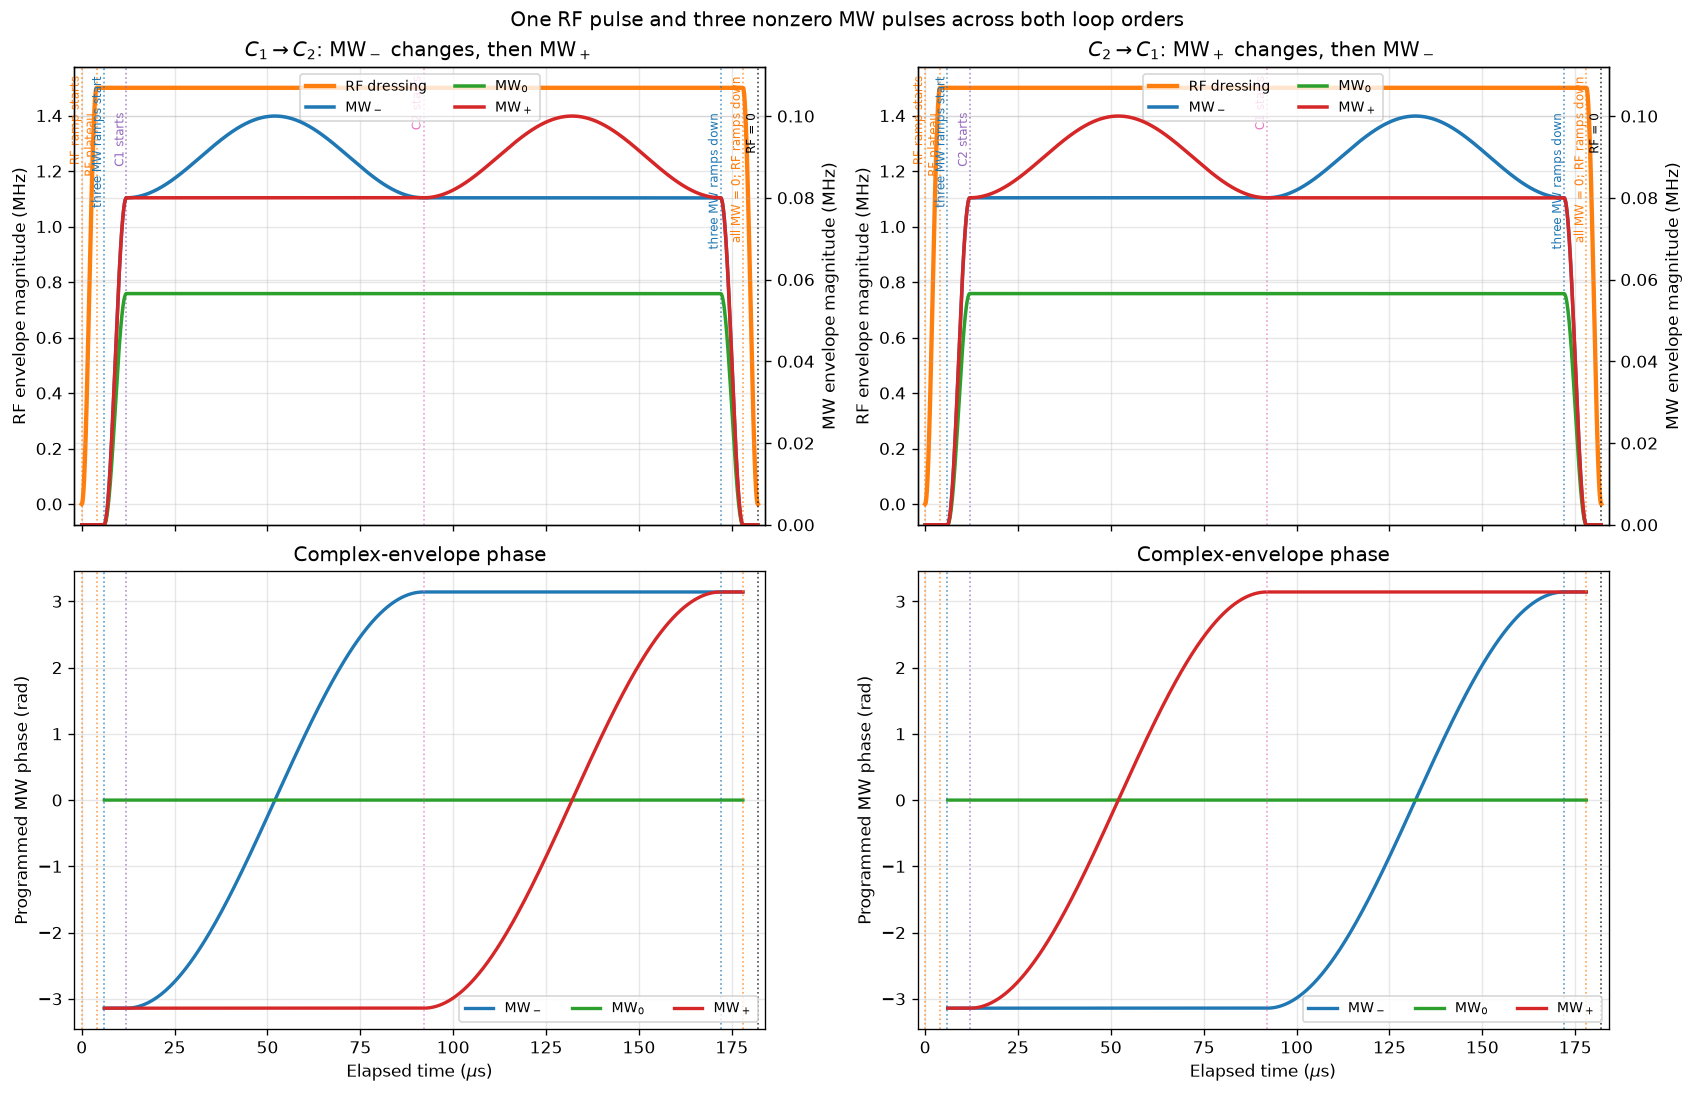

In [43]:
# =============================================================================
# 7.3 Display all four physical pulse envelopes and their phase loops
# =============================================================================
loop_control_times_us = np.linspace(0.0, loop_sequence_duration_us, 2401)
rf_loop_amplitude_mhz = RF_RABI_MHZ * rf_loop_envelope(loop_control_times_us)
mw_pulse_labels = (r"MW$_-$", r"MW$_0$", r"MW$_+$")
mw_pulse_colors = ("tab:blue", "tab:green", "tab:red")

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, constrained_layout=True)
for column, (loop_order, order_title) in enumerate((
    (("C1", "C2"), r"$C_1\rightarrow C_2$: MW$_-$ changes, then MW$_+$"),
    (("C2", "C1"), r"$C_2\rightarrow C_1$: MW$_+$ changes, then MW$_-$"),
)):
    complex_mw_envelopes = np.array([
        np.array([
            mw_leg_complex_envelope(time_us, loop_order, leg_index)
            for time_us in loop_control_times_us
        ])
        for leg_index in range(3)
    ])
    mw_magnitudes_mhz = np.abs(Omega_bare_mhz)[:, None] * np.abs(complex_mw_envelopes)

    amplitude_ax = axes[0, column]
    mw_amplitude_ax = amplitude_ax.twinx()
    rf_line = amplitude_ax.plot(
        loop_control_times_us,
        rf_loop_amplitude_mhz,
        color="tab:orange",
        lw=2.6,
        label="RF dressing",
    )[0]
    mw_lines = []
    for magnitude, label, color in zip(
        mw_magnitudes_mhz, mw_pulse_labels, mw_pulse_colors
    ):
        mw_lines.append(mw_amplitude_ax.plot(
            loop_control_times_us,
            magnitude,
            color=color,
            lw=2.1,
            label=label,
        )[0])
    mark_loop_sequence_events(amplitude_ax, loop_order, annotate=True)
    amplitude_ax.set(
        xlim=(-2.0, loop_sequence_duration_us + 2.0),
        ylabel="RF envelope magnitude (MHz)",
        title=order_title,
    )
    mw_amplitude_ax.set(
        ylim=(0.0, 1.12 * np.max(mw_magnitudes_mhz)),
        ylabel="MW envelope magnitude (MHz)",
    )
    amplitude_ax.legend(
        [rf_line, *mw_lines],
        [line.get_label() for line in (rf_line, *mw_lines)],
        ncol=2,
        fontsize=8.5,
        loc="upper center",
    )

    # Plot the programmed argument of each complex MW envelope. Phase is masked
    # before MW turn-on and after MW turn-off because a zero-amplitude pulse has
    # no physically defined phase.
    phase_ax = axes[1, column]
    for complex_envelope, label, color in zip(
        complex_mw_envelopes, mw_pulse_labels, mw_pulse_colors
    ):
        programmed_phase = -np.unwrap(np.angle(complex_envelope))
        programmed_phase[np.abs(complex_envelope) < 1e-10] = np.nan
        phase_ax.plot(
            loop_control_times_us,
            programmed_phase,
            color=color,
            lw=2.0,
            label=label,
        )
    mark_loop_sequence_events(phase_ax, loop_order, annotate=False)
    phase_ax.set(
        xlim=(-2.0, loop_sequence_duration_us + 2.0),
        xlabel=r"Elapsed time ($\mu$s)",
        ylabel="Programmed MW phase (rad)",
        title="Complex-envelope phase",
    )
    phase_ax.legend(ncol=3, fontsize=8.5)

    # Every MW pulse must be strictly nonzero during both loop intervals.
    loop_mask = (
        (loop_control_times_us >= t_loop_1_start_us)
        & (loop_control_times_us <= t_mw_ramp_down_start_us)
    )
    assert np.all(mw_magnitudes_mhz[:, loop_mask] > 0.0)

fig.suptitle("One RF pulse and three nonzero MW pulses across both loop orders")
plt.show()

#### Reading the four-envelope figure

**How the figure was generated.** Each column is one chronological loop-order experiment. The upper panels display the magnitude of every physical control: one orange RF envelope and three independently calibrated MW envelopes. The active MW pulse develops a smooth positive bump during its assigned loop: MW$_-$ for $C_1$ and MW$_+$ for $C_2$. The other two MW pulses remain on at their plateau values. The lower panels show the phase stored in the same three complex MW envelopes; only the pulse assigned to the active loop winds by $2\pi$.

**Physical intuition.** The RF field first isolates the dressed ancilla. Turning on all three MW pulses opens the tripod bright-dark gap. During each loop, the selected complex MW amplitude moves around a closed path because both its magnitude and phase return to their starting values. The nonzero plateaus prevent an unintended loss of one tripod leg at the boundary between loops. All three MW pulses are then ramped down before the RF dressing is removed.

**Paper comparison.** The phase traces reproduce Equations (8)-(10). The visible magnitude bumps are the requested extension. Set `mw_loop_amplitude_bump_depth = 0.0` to remove the bumps and reproduce the paper's fixed-magnitude loop prescription.

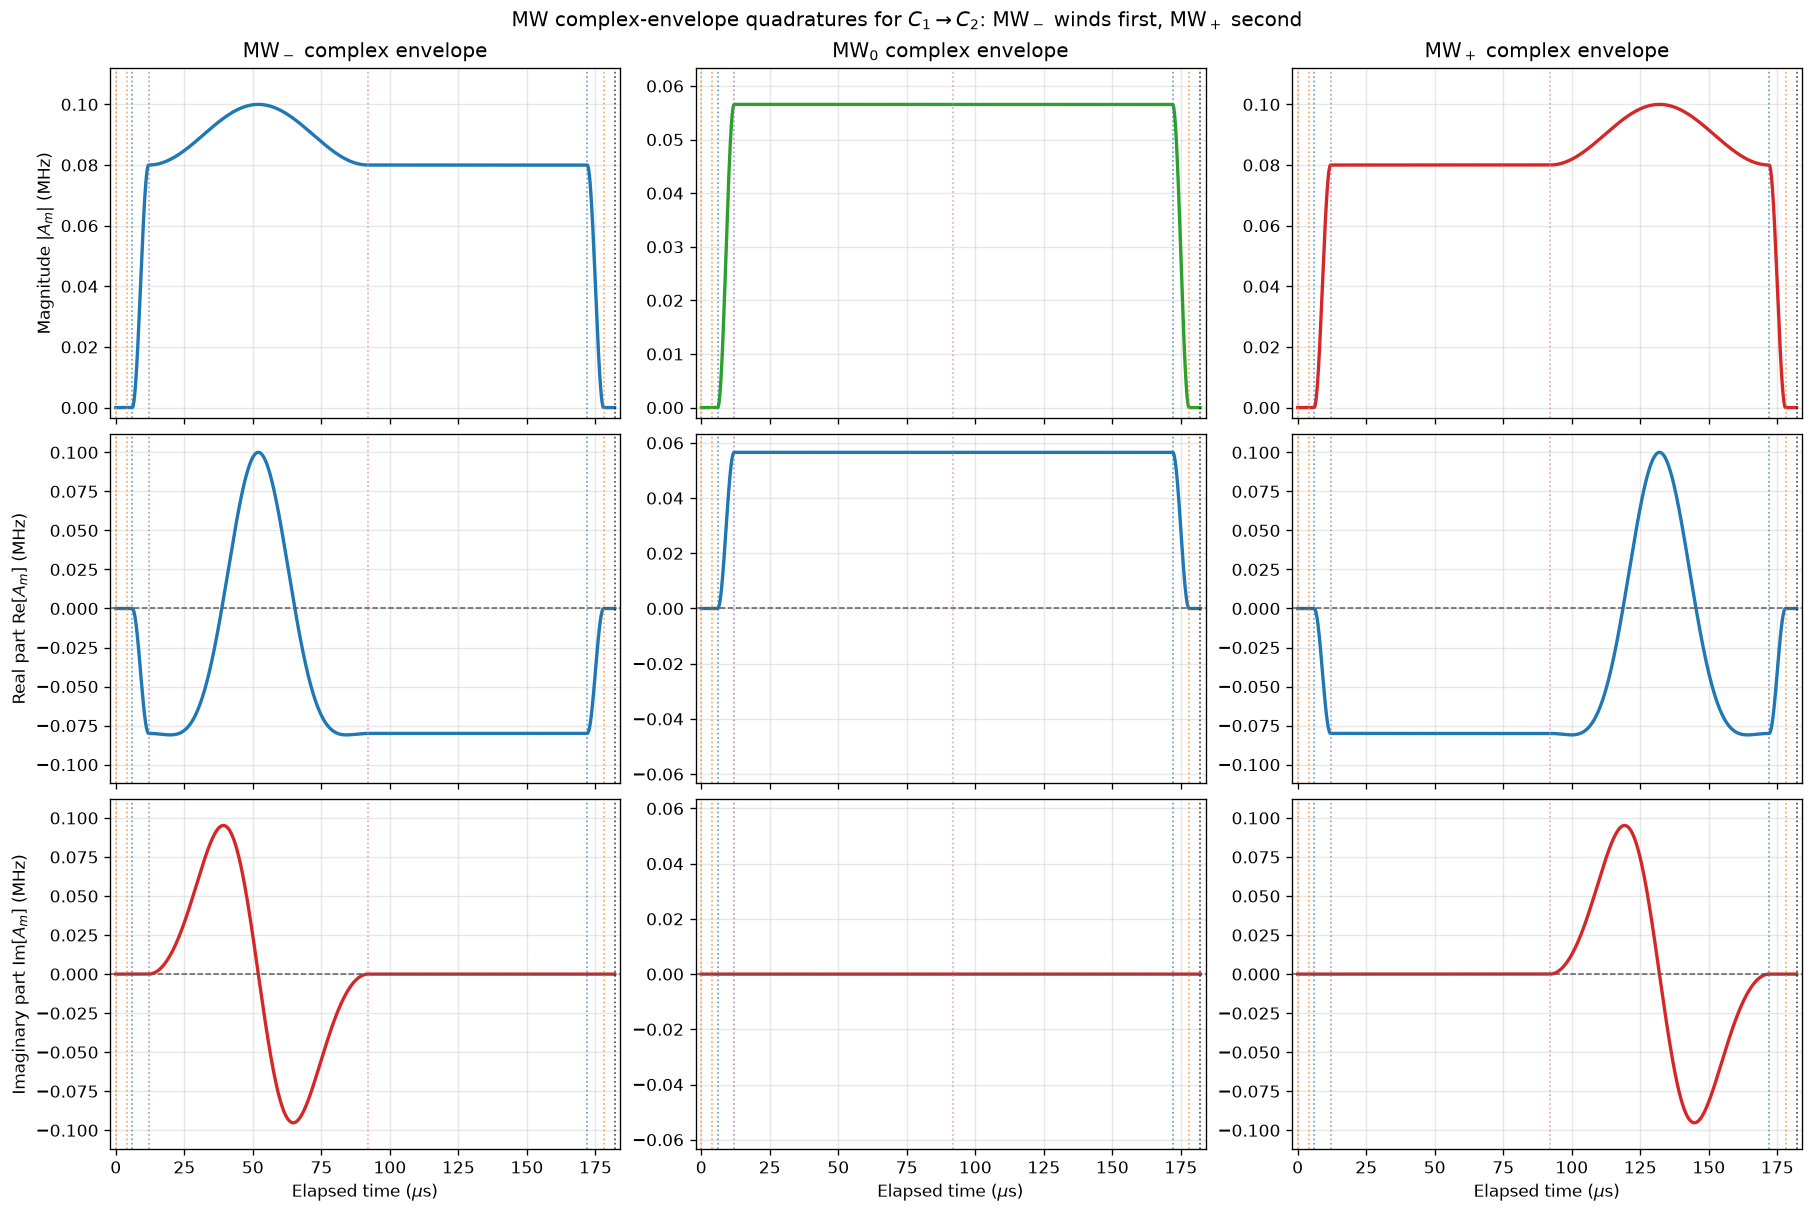

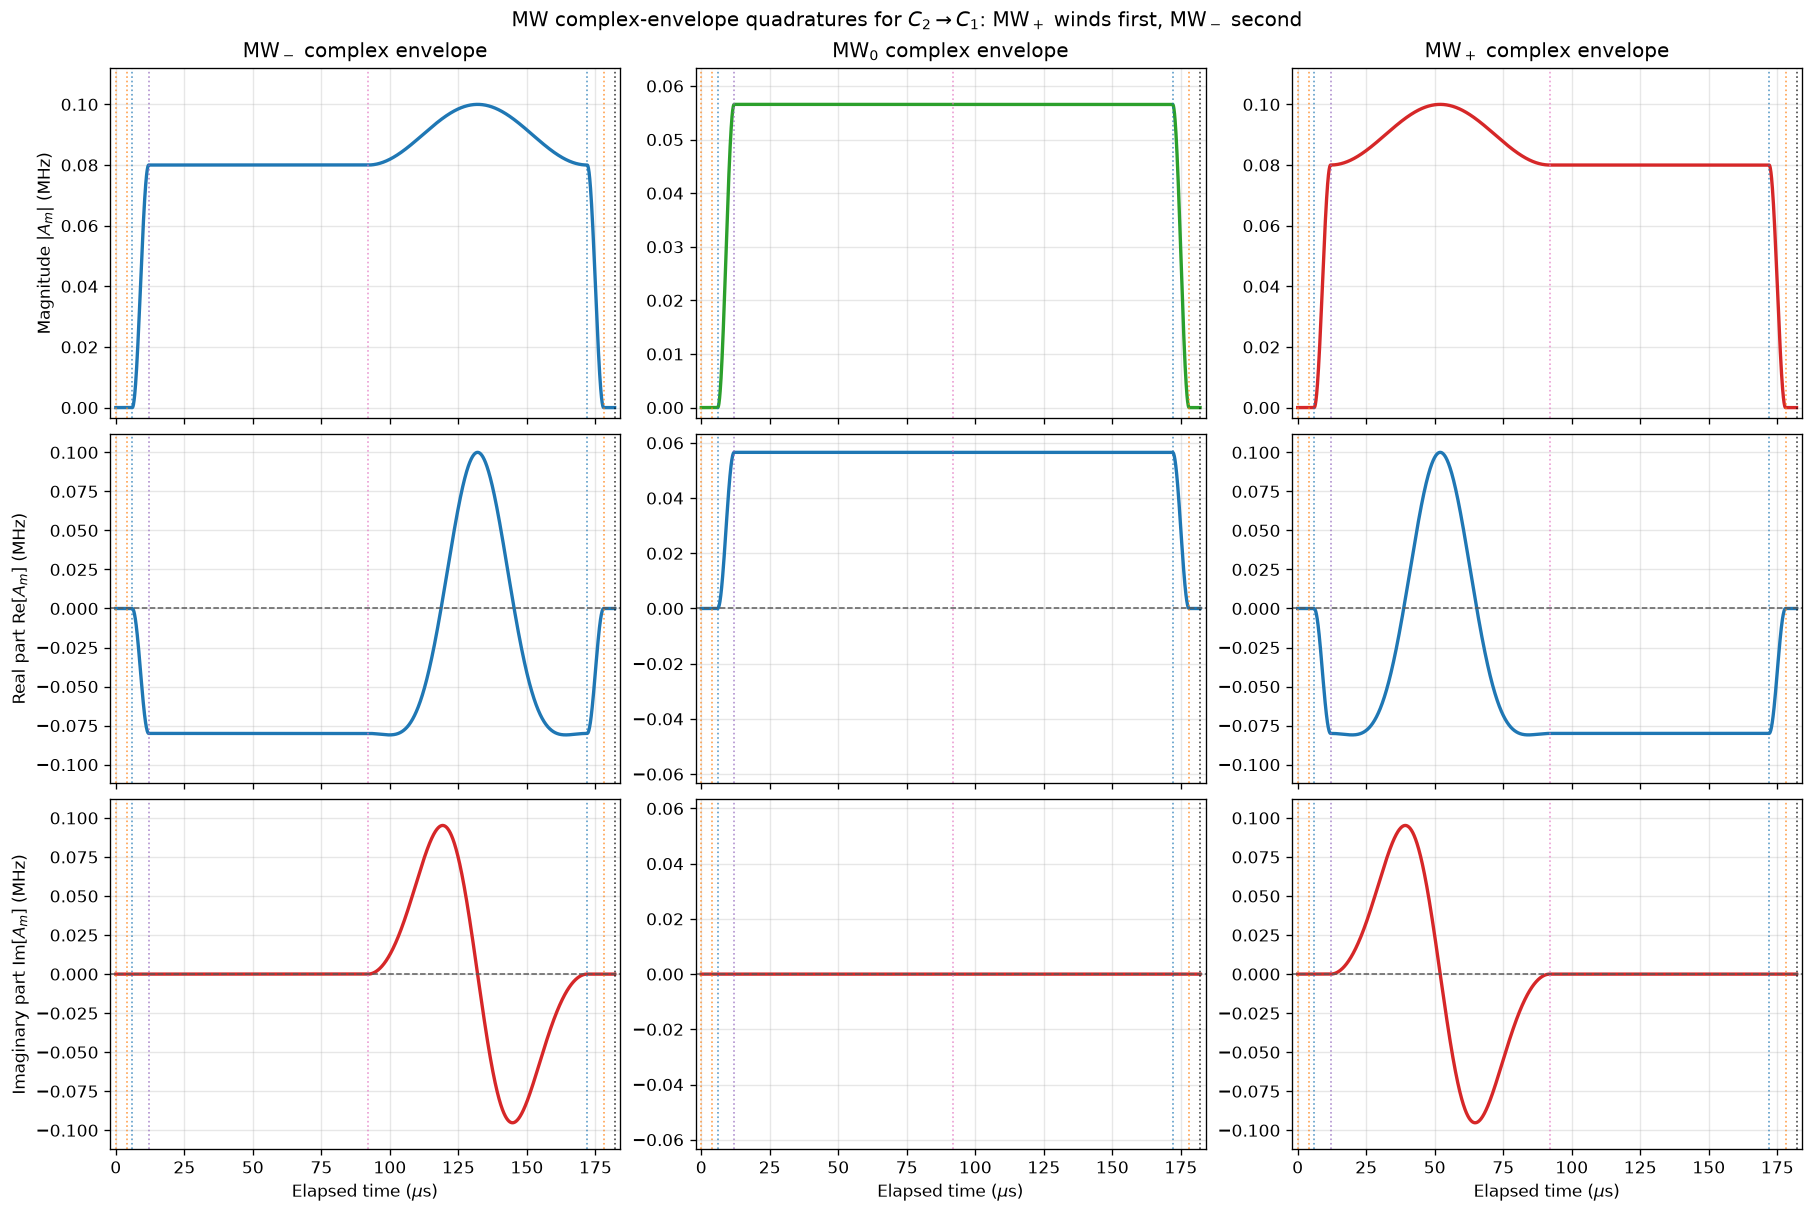

In [44]:
# =============================================================================
# 7.4 Plot the magnitude, real part, and imaginary part of every MW envelope
# =============================================================================
# Each column is one of the three physical MW pulses. Each row is a different
# view of the SAME complex rotating-frame coefficient:
#
#     A_m(t) = Omega_bare_m * envelope_m(t)
#            = |A_m(t)| exp[-i phi_m(t)].
#
# Therefore Re[A_m] is the in-phase (I) component. Im[A_m] is the imaginary
# component; with this exp(-i phi) convention, hardware Q = -Im[A_m].
quadrature_times_us = np.linspace(0.0, loop_sequence_duration_us, 2401)
quadrature_mw_labels = (r"MW$_-$", r"MW$_0$", r"MW$_+$")
quadrature_mw_colors = ("tab:blue", "tab:green", "tab:red")
quadrature_loop_orders = (
    (("C1", "C2"), r"$C_1\rightarrow C_2$: MW$_-$ winds first, MW$_+$ second"),
    (("C2", "C1"), r"$C_2\rightarrow C_1$: MW$_+$ winds first, MW$_-$ second"),
)
quadrature_row_labels = (
    r"Magnitude $|A_m|$ (MHz)",
    r"Real part $\mathrm{Re}[A_m]$ (MHz)",
    r"Imaginary part $\mathrm{Im}[A_m]$ (MHz)",
)
mw_quadrature_results = {}

for loop_order, figure_title in quadrature_loop_orders:
    complex_drives_mhz = np.array([
        Omega_bare_mhz[leg_index] * np.array([
            mw_leg_complex_envelope(time_us, loop_order, leg_index)
            for time_us in quadrature_times_us
        ])
        for leg_index in range(3)
    ])
    component_rows = (
        np.abs(complex_drives_mhz),
        np.real(complex_drives_mhz),
        np.imag(complex_drives_mhz),
    )
    mw_quadrature_results[loop_order] = {
        "times_us": quadrature_times_us.copy(),
        "complex_drives_mhz": complex_drives_mhz.copy(),
        "magnitude_mhz": component_rows[0].copy(),
        "real_mhz": component_rows[1].copy(),
        "imaginary_mhz": component_rows[2].copy(),
    }

    fig, axes = plt.subplots(
        3, 3, figsize=(15, 10), sharex=True, constrained_layout=True
    )
    for leg_index, (leg_label, leg_color) in enumerate(zip(
        quadrature_mw_labels, quadrature_mw_colors
    )):
        amplitude_limit = 1.12 * np.max(np.abs(complex_drives_mhz[leg_index]))
        for row_index, (row_values, row_label) in enumerate(zip(
            component_rows, quadrature_row_labels
        )):
            ax = axes[row_index, leg_index]
            color = leg_color if row_index == 0 else (
                "tab:blue" if row_index == 1 else "tab:red"
            )
            ax.plot(quadrature_times_us, row_values[leg_index], color=color, lw=2.0)
            mark_loop_sequence_events(ax, loop_order, annotate=False)
            if row_index == 0:
                ax.set_ylim(-0.03 * amplitude_limit, amplitude_limit)
                ax.set_title(leg_label + " complex envelope")
            else:
                ax.axhline(0.0, color="0.35", ls="--", lw=0.9)
                ax.set_ylim(-amplitude_limit, amplitude_limit)
            ax.set_xlim(-2.0, loop_sequence_duration_us + 2.0)
            if leg_index == 0:
                ax.set_ylabel(row_label)
            if row_index == 2:
                ax.set_xlabel(r"Elapsed time ($\mu$s)")

    fig.suptitle("MW complex-envelope quadratures for " + figure_title)
    plt.show()

# Numerical checks: all three pulses remain nonzero during the two loop windows,
# and the plotted real/imaginary components reconstruct each complex envelope.
loop_mask_for_quadratures = (
    (quadrature_times_us >= t_loop_1_start_us)
    & (quadrature_times_us <= t_mw_ramp_down_start_us)
)
for result in mw_quadrature_results.values():
    assert np.all(result["magnitude_mhz"][:, loop_mask_for_quadratures] > 0.0)
    reconstructed = result["real_mhz"] + 1j * result["imaginary_mhz"]
    assert np.allclose(reconstructed, result["complex_drives_mhz"], atol=1e-14)

#### Reading the 3x3 MW quadrature figures

**Layout.** Each figure represents one chronological loop ordering. The columns are the three physical pulses MW$_-$, MW$_0$, and MW$_+$. The rows show the magnitude, real part, and imaginary part of the same complex envelope $A_m(t)$.

**What the oscillations mean.** The magnitude row contains the smooth turn-on, the optional positive amplitude bump, and the turn-off. The phase winding appears in the lower two rows because

$$
\mathrm{Re}[A_m]=|A_m|\cos\phi_m,
\qquad
\mathrm{Im}[A_m]=-|A_m|\sin\phi_m
$$

for the notebook's $e^{-i\phi_m}$ convention. Thus MW$_-$ completes one quadrature cycle during $C_1$, MW$_+$ completes one during $C_2$, and MW$_0$ retains its fixed reference phase. Reversing the loop order reverses when the MW$_-$ and MW$_+$ cycles occur.

**Why the curves are not perfect time-domain sinusoids.** Equation (10) uses the endpoint-smoothed phase $\phi(t)=2\pi\sin^2(\pi t/2T)$ rather than a linear phase ramp. The complex envelope still makes one complete rotation, but its angular speed starts and ends at zero. These are rotating-frame envelopes; the much faster GHz laboratory carrier is intentionally not plotted.

In [45]:
# =============================================================================
# 7.5 Run one four-pulse PulsedSim experiment for each loop ordering
# =============================================================================
loop_population_observables = [
    P_g_minus,
    P_g_zero,
    P_g_plus,
    P_excited,
    P_higher_excited_total,
    P_ground_total,
    P_tripod,
    P_all_states,
]
loop_population_labels = (
    r"$P_{g_-}$",
    r"$P_{g_0}$",
    r"$P_{g_+}$",
    r"$P_e$",
    r"$P_{e_0}+P_{e_+}$",
    r"$P_G$",
    r"$P_{g_-}+P_{g_0}+P_{g_+}+P_e$",
    r"$P_{\rm all}$",
)


class FourPulseTrajectoryPulsedSim(PulsedSim):
    """QuaCCAToo PulsedSim that retains the ket at every solver time.

    The base `PulsedSim.add_pulse` keeps only the final state. This small,
    transparent extension uses the same system, time-unit convention, and
    QuTiP `mesolve` mechanism, but stores all evolved kets so their basis-state
    phases can be plotted. It also accepts each phase-programmed MW tone as one
    complex physical pulse rather than exposing its I and Q quadratures as two
    separate pulse entries.
    """

    def add_four_physical_pulses(
        self,
        duration_us,
        loop_order,
        time_steps,
        options=None,
    ):
        """Propagate one RF pulse and three complex MW pulses simultaneously.

        Parameters
        ----------
        duration_us : float
            Total sequence duration in microseconds.
        loop_order : tuple of str
            Chronological pair ('C1','C2') or ('C2','C1').
        time_steps : int
            Number of stored solver samples across the complete experiment.
        options : dict or None
            QuTiP solver tolerances and integration limits.

        Returns
        -------
        None
            The final ket is stored in `rho`; all intermediate kets and times
            are stored in `evolved_states` and `evolved_times_us`.
        """
        if tuple(loop_order) not in (("C1", "C2"), ("C2", "C1")):
            raise ValueError("loop_order must be ('C1','C2') or ('C2','C1')")
        if duration_us <= 0.0 or time_steps < 2:
            raise ValueError("duration_us must be positive and time_steps at least two")
        if options is None:
            options = {}

        def rf_shape(solver_time):
            physical_time_us = solver_time / (2.0 * np.pi)
            return rf_loop_envelope(physical_time_us)

        def make_mw_shape(leg_index):
            def mw_shape(solver_time):
                physical_time_us = solver_time / (2.0 * np.pi)
                return mw_leg_complex_envelope(
                    physical_time_us,
                    loop_order,
                    leg_index,
                )
            return mw_shape

        mw_shapes = [make_mw_shape(leg_index) for leg_index in range(3)]
        start_time_us = float(self.total_time)
        self.evolved_times_us = np.linspace(
            start_time_us,
            start_time_us + duration_us,
            int(time_steps),
        )
        solver_times = 2.0 * np.pi * self.evolved_times_us

        # These are the only four physical pulse profiles in this experiment.
        self.physical_pulse_profiles = [
            (FOUR_PHYSICAL_PULSE_NAMES[0], H_rf_loop_control_mhz, rf_shape),
            *[
                (name, operator, shape)
                for name, operator, shape in zip(
                    FOUR_PHYSICAL_PULSE_NAMES[1:],
                    mw_forward_operators_mhz,
                    mw_shapes,
                )
            ],
        ]
        self.pulse_profiles = [
            [operator, self.evolved_times_us.copy(), shape, {"physical_pulse": name}]
            for name, operator, shape in self.physical_pulse_profiles
        ]
        assert len(self.physical_pulse_profiles) == 4
        assert len(self.pulse_profiles) == 4

        def complete_hamiltonian(solver_time, _args=None):
            hamiltonian = self.system.H0 + rf_shape(solver_time) * H_rf_loop_control_mhz
            for forward_operator, mw_shape in zip(mw_forward_operators_mhz, mw_shapes):
                complex_amplitude = mw_shape(solver_time)
                hamiltonian += (
                    complex_amplitude * forward_operator
                    + np.conjugate(complex_amplitude) * forward_operator.dag()
                )
            return hamiltonian

        solution = mesolve(
            complete_hamiltonian,
            self.rho,
            solver_times,
            self.system.c_ops,
            options=options,
        )
        self.evolved_states = tuple(state.copy() for state in solution.states)
        self.rho = self.evolved_states[-1].copy()
        self.total_time = start_time_us + duration_us


def run_four_pulse_loop_order(loop_order, reporting_step_us=0.5):
    """Run one complete four-pulse experiment and calculate observables.

    Parameters
    ----------
    loop_order : tuple of str
        Chronological pair ('C1','C2') or ('C2','C1').
    reporting_step_us : float
        Requested interval between stored state vectors in microseconds.

    Returns
    -------
    dict
        Loop order, physical times, all evolved nine-state kets, an N-by-8
        population array, final ket, and the four-pulse PulsedSim object.
    """
    if reporting_step_us <= 0.0:
        raise ValueError("reporting_step_us must be positive")
    sample_count = int(np.ceil(loop_sequence_duration_us / reporting_step_us)) + 1
    system = QSys(
        H0=H_loop_static_mhz,
        rho0=loop_order_initial_state,
        observable=None,
        units_H0="MHz",
    )
    experiment = FourPulseTrajectoryPulsedSim(system)
    experiment.add_four_physical_pulses(
        duration_us=loop_sequence_duration_us,
        loop_order=loop_order,
        time_steps=sample_count,
        options={"nsteps": 100000, "atol": 1e-10, "rtol": 1e-9},
    )
    populations = np.array([
        [
            float(np.real(expect(observable, state)))
            for observable in loop_population_observables
        ]
        for state in experiment.evolved_states
    ])
    assert len(experiment.physical_pulse_profiles) == 4
    assert np.allclose(populations[:, 7], 1.0, atol=1e-7)
    return {
        "order": tuple(loop_order),
        "times_us": experiment.evolved_times_us.copy(),
        "states": experiment.evolved_states,
        "populations": populations,
        "final_state": experiment.rho.copy(),
        "experiment": experiment,
    }


# Variable names retain the corresponding mathematical product convention:
# chronological C1 then C2 produces U(C2)U(C1), and vice versa.
loop_result_C2C1 = run_four_pulse_loop_order(("C1", "C2"), loop_reporting_step_us)
loop_result_C1C2 = run_four_pulse_loop_order(("C2", "C1"), loop_reporting_step_us)

for result in (loop_result_C2C1, loop_result_C1C2):
    populations = result["populations"]
    print("Chronological loop order:", result["order"])
    print("  physical pulse count:", len(result["experiment"].physical_pulse_profiles))
    print("  stored evolved kets:", len(result["states"]))
    print("  maximum normalization error:", np.max(np.abs(populations[:, 7] - 1.0)))
    print("  maximum selected-ancilla population:", np.max(populations[:, 3]))
    print("  maximum higher-dressed population:", np.max(populations[:, 4]))
    print("  final requested populations:", populations[-1])

Chronological loop order: ('C1', 'C2')
  physical pulse count: 4
  stored evolved kets: 365
  maximum normalization error: 6.661338147750939e-16
  maximum selected-ancilla population: 0.06271078024207903
  maximum higher-dressed population: 0.0012990998708767073
  final requested populations: [3.10419846e-01 6.23824878e-01 6.54809645e-02 2.74307857e-04
 3.64613512e-09 9.99725688e-01 9.99999996e-01 1.00000000e+00]
Chronological loop order: ('C2', 'C1')
  physical pulse count: 4
  stored evolved kets: 365
  maximum normalization error: 6.661338147750939e-16
  maximum selected-ancilla population: 0.02700086888531042
  maximum higher-dressed population: 0.0013533488454423345
  final requested populations: [2.87621630e-01 5.51778920e-02 6.56934168e-01 2.66310113e-04
 4.70027386e-10 9.99733689e-01 1.00000000e+00 1.00000000e+00]


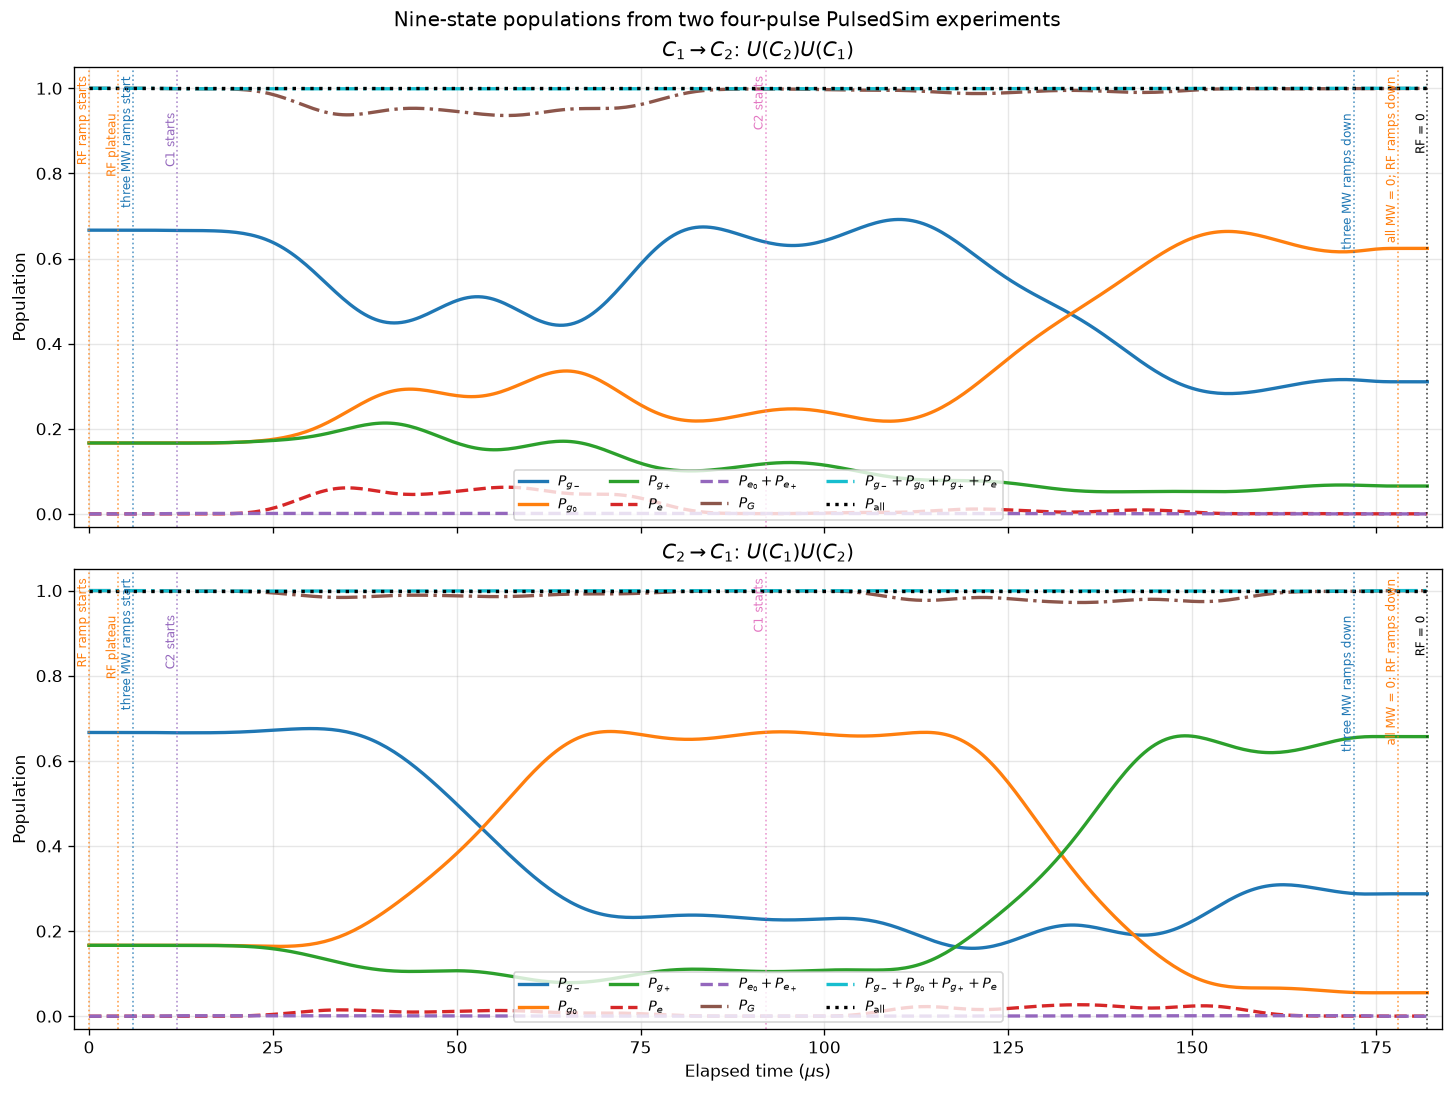

Final C1 -> C2 populations: [3.10419846e-01 6.23824878e-01 6.54809645e-02 2.74307857e-04
 3.64613512e-09 9.99725688e-01 9.99999996e-01 1.00000000e+00]
Final C2 -> C1 populations: [2.87621630e-01 5.51778920e-02 6.56934168e-01 2.66310113e-04
 4.70027386e-10 9.99733689e-01 1.00000000e+00 1.00000000e+00]
Final ground-state population-order contrast: 0.8207898908983294


In [46]:
# =============================================================================
# 7.6 Plot populations from the stored PulsedSim ket trajectories
# =============================================================================
population_colors = (
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:cyan",
    "black",
)
population_styles = ("-", "-", "-", "--", "--", "-.", "-.", ":")

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True, sharey=True, constrained_layout=True)
for ax, result, title in (
    (axes[0], loop_result_C2C1, r"$C_1\rightarrow C_2$: $U(C_2)U(C_1)$"),
    (axes[1], loop_result_C1C2, r"$C_2\rightarrow C_1$: $U(C_1)U(C_2)$"),
):
    for column, (label, color, style) in enumerate(zip(
        loop_population_labels,
        population_colors,
        population_styles,
    )):
        ax.plot(
            result["times_us"],
            result["populations"][:, column],
            color=color,
            ls=style,
            lw=2.0,
            label=label,
        )
    mark_loop_sequence_events(ax, result["order"], annotate=True)
    ax.set(
        xlim=(-2.0, loop_sequence_duration_us + 2.0),
        ylim=(-0.03, 1.05),
        ylabel="Population",
        title=title,
    )
    ax.legend(ncol=4, fontsize=8.3, loc="lower center")

axes[1].set_xlabel(r"Elapsed time ($\mu$s)")
fig.suptitle("Nine-state populations from two four-pulse PulsedSim experiments")
plt.show()

final_populations_C2C1 = loop_result_C2C1["populations"][-1]
final_populations_C1C2 = loop_result_C1C2["populations"][-1]
ground_population_order_contrast = np.linalg.norm(
    final_populations_C2C1[:3] - final_populations_C1C2[:3]
)
print("Final C1 -> C2 populations:", final_populations_C2C1)
print("Final C2 -> C1 populations:", final_populations_C1C2)
print("Final ground-state population-order contrast:", ground_population_order_contrast)

#### Reading the population plots

**How the plots were generated.** Each row comes from one continuous `FourPulseTrajectoryPulsedSim` propagation. The code evaluates the eight projectors directly on every stored evolved ket; no measurement or state collapse occurs at the event markers. The curves include the three ground states, selected ancilla, two higher RF-dressed states, total ground population, intended tripod population, and the complete nine-state norm.

**Physical intuition.** The RF pulse does not change the initially prepared $m_s=0$ state because it acts only in the $m_s=-1$ manifold. Once all three MW pulses are nonzero, the state follows the driven tripod eigenstructure. Changing the MW$_-$ complex amplitude and then MW$_+$ traces a different ordered Hamiltonian path from changing MW$_+$ and then MW$_-$. The resulting population difference is the directly visible order-swap signature. Small $P_e$ is consistent with mostly dark-state following; population in $|e_0\rangle$ and $|e_+\rangle$ measures imperfect isolation from the other RF-dressed branches.

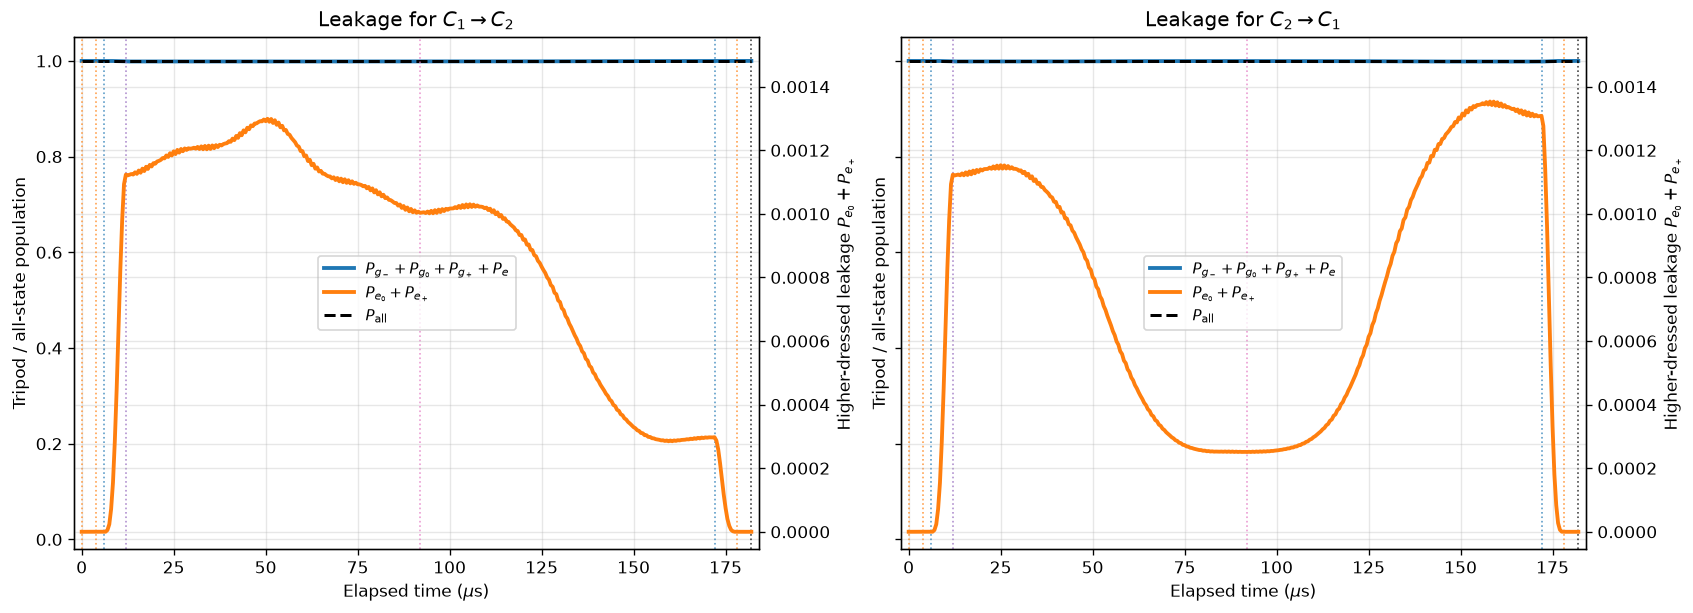

('C1', 'C2') max higher-dressed leakage = 0.0012990998708767073 ; max spectator population = 4.115631446754975e-16
('C2', 'C1') max higher-dressed leakage = 0.0013533488454423345 ; max spectator population = 5.277896175659436e-16


In [47]:
# =============================================================================
# 7.7 Isolate leakage into the two unwanted RF-dressed branches
# =============================================================================
maximum_higher_dressed_population = max(
    np.max(loop_result_C2C1["populations"][:, 4]),
    np.max(loop_result_C1C2["populations"][:, 4]),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, result, title in (
    (axes[0], loop_result_C2C1, r"Leakage for $C_1\rightarrow C_2$"),
    (axes[1], loop_result_C1C2, r"Leakage for $C_2\rightarrow C_1$"),
):
    times_us = result["times_us"]
    populations = result["populations"]
    tripod_line = ax.plot(
        times_us,
        populations[:, 6],
        lw=2.3,
        color="tab:blue",
        label=r"$P_{g_-}+P_{g_0}+P_{g_+}+P_e$",
    )[0]
    all_state_line = ax.plot(
        times_us,
        populations[:, 7],
        lw=1.8,
        ls="--",
        color="black",
        label=r"$P_{\rm all}$",
    )[0]
    leakage_axis = ax.twinx()
    leakage_line = leakage_axis.plot(
        times_us,
        populations[:, 4],
        lw=2.3,
        color="tab:orange",
        label=r"$P_{e_0}+P_{e_+}$",
    )[0]
    mark_loop_sequence_events(ax, result["order"], annotate=False)
    ax.set(
        xlim=(-2.0, loop_sequence_duration_us + 2.0),
        ylim=(-0.02, 1.05),
        xlabel=r"Elapsed time ($\mu$s)",
        ylabel="Tripod / all-state population",
        title=title,
    )
    leakage_axis.set(
        ylim=(
            -0.04 * maximum_higher_dressed_population,
            1.15 * maximum_higher_dressed_population,
        ),
        ylabel=r"Higher-dressed leakage $P_{e_0}+P_{e_+}$",
    )
    ax.legend(
        [tripod_line, leakage_line, all_state_line],
        [line.get_label() for line in (tripod_line, leakage_line, all_state_line)],
        fontsize=9,
        loc="center",
    )

plt.show()

for result in (loop_result_C2C1, loop_result_C1C2):
    populations = result["populations"]
    spectator_population = populations[:, 7] - populations[:, 6] - populations[:, 4]
    print(
        result["order"],
        "max higher-dressed leakage =",
        np.max(populations[:, 4]),
        "; max spectator population =",
        np.max(np.abs(spectator_population)),
    )

#### Reading the leakage plots

**How the plots were generated.** The blue curve is the intended four-state tripod population, the orange curve is the combined population in $|e_0\rangle$ and $|e_+\rangle$, and the dashed black curve verifies the full nine-state normalization. The leakage uses a separate right-hand axis because it is much smaller than the normalized population.

**Physical intuition.** Each physical MW pulse addresses a bare $m_s=-1$ state, and every bare state contains components of all three RF-dressed eigenstates. The selected $|e\rangle$ branch is resonant, whereas $|e_0\rangle$ and $|e_+\rangle$ are separated by the RF dressing gap. Slow, smooth changes suppress transitions to those unwanted branches. Any remaining gap between the tripod plus dressed-leakage curves and $P_{\rm all}$ would be population in the retained $m_s=+1$ spectator manifold.

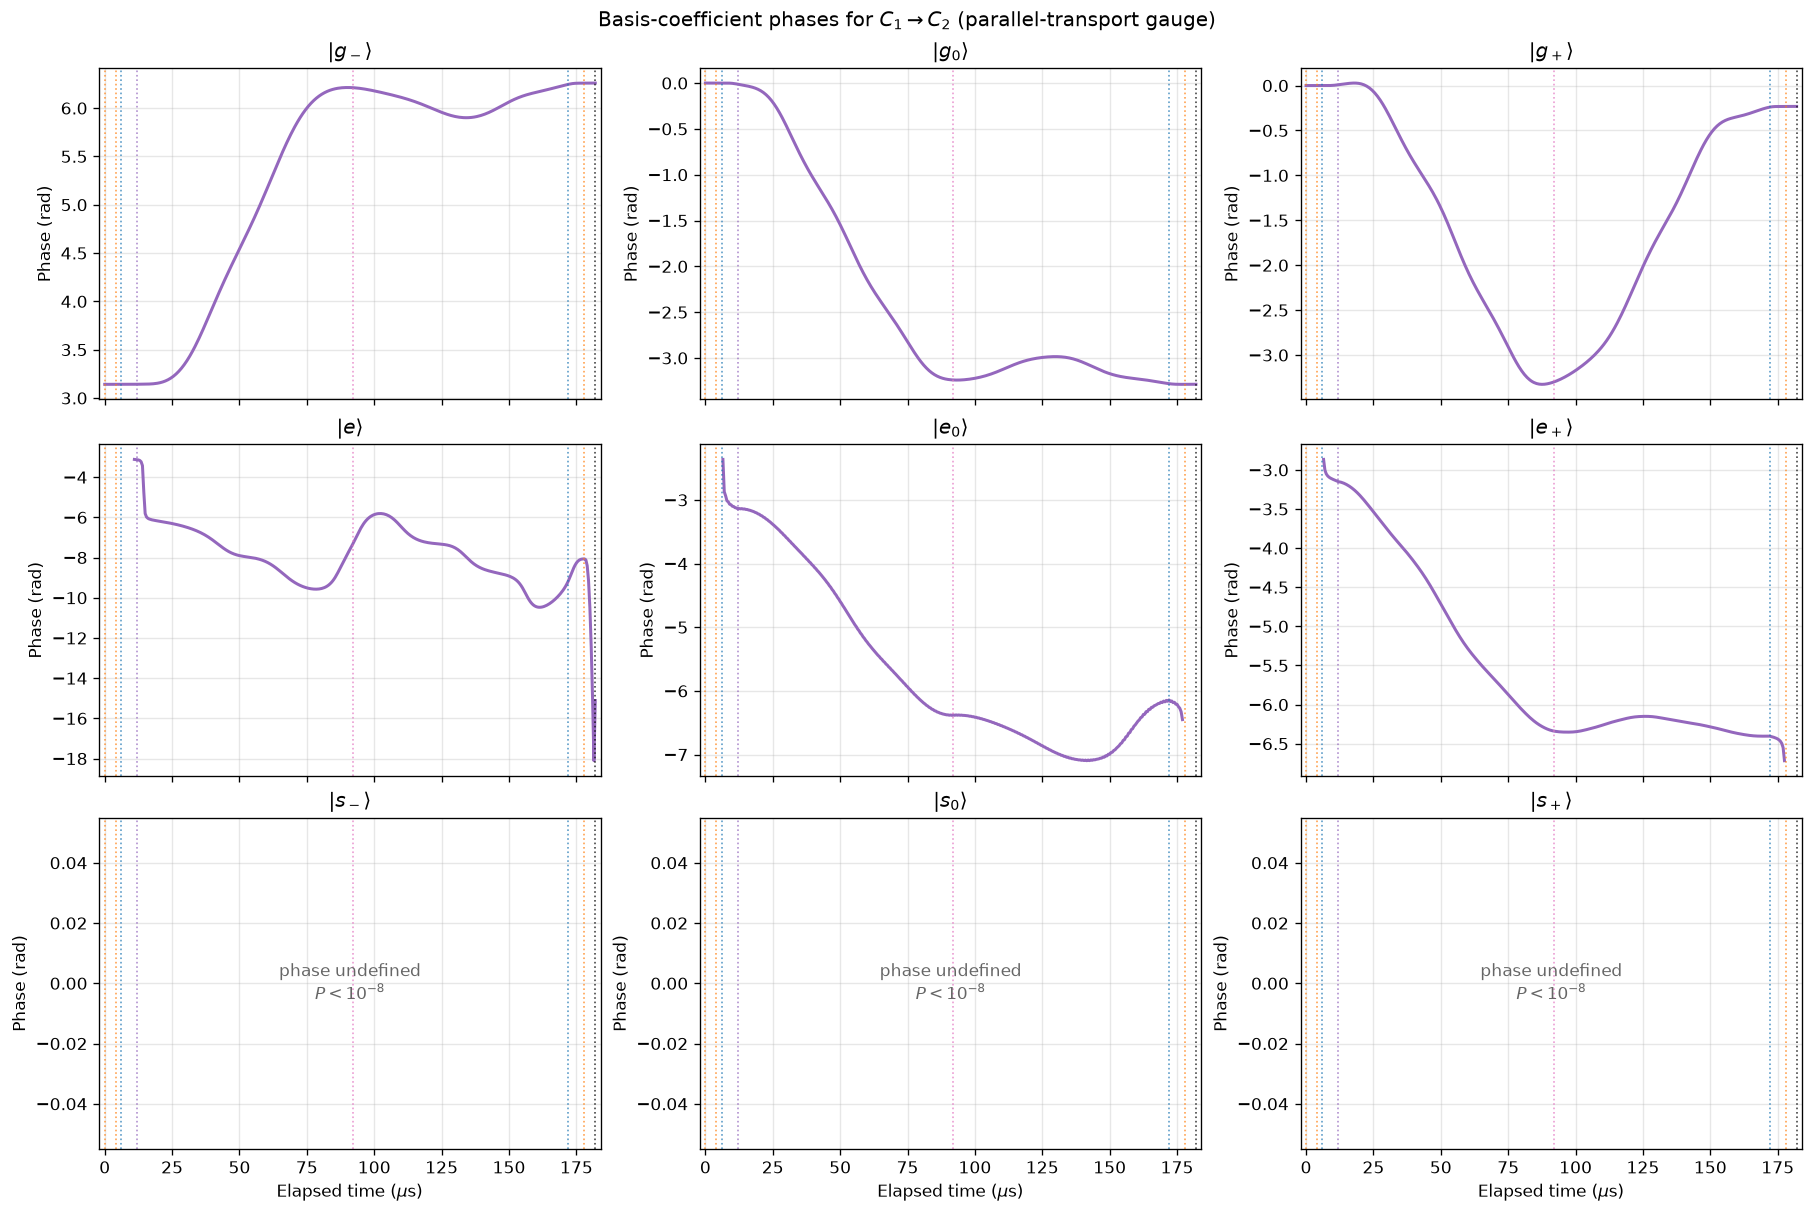

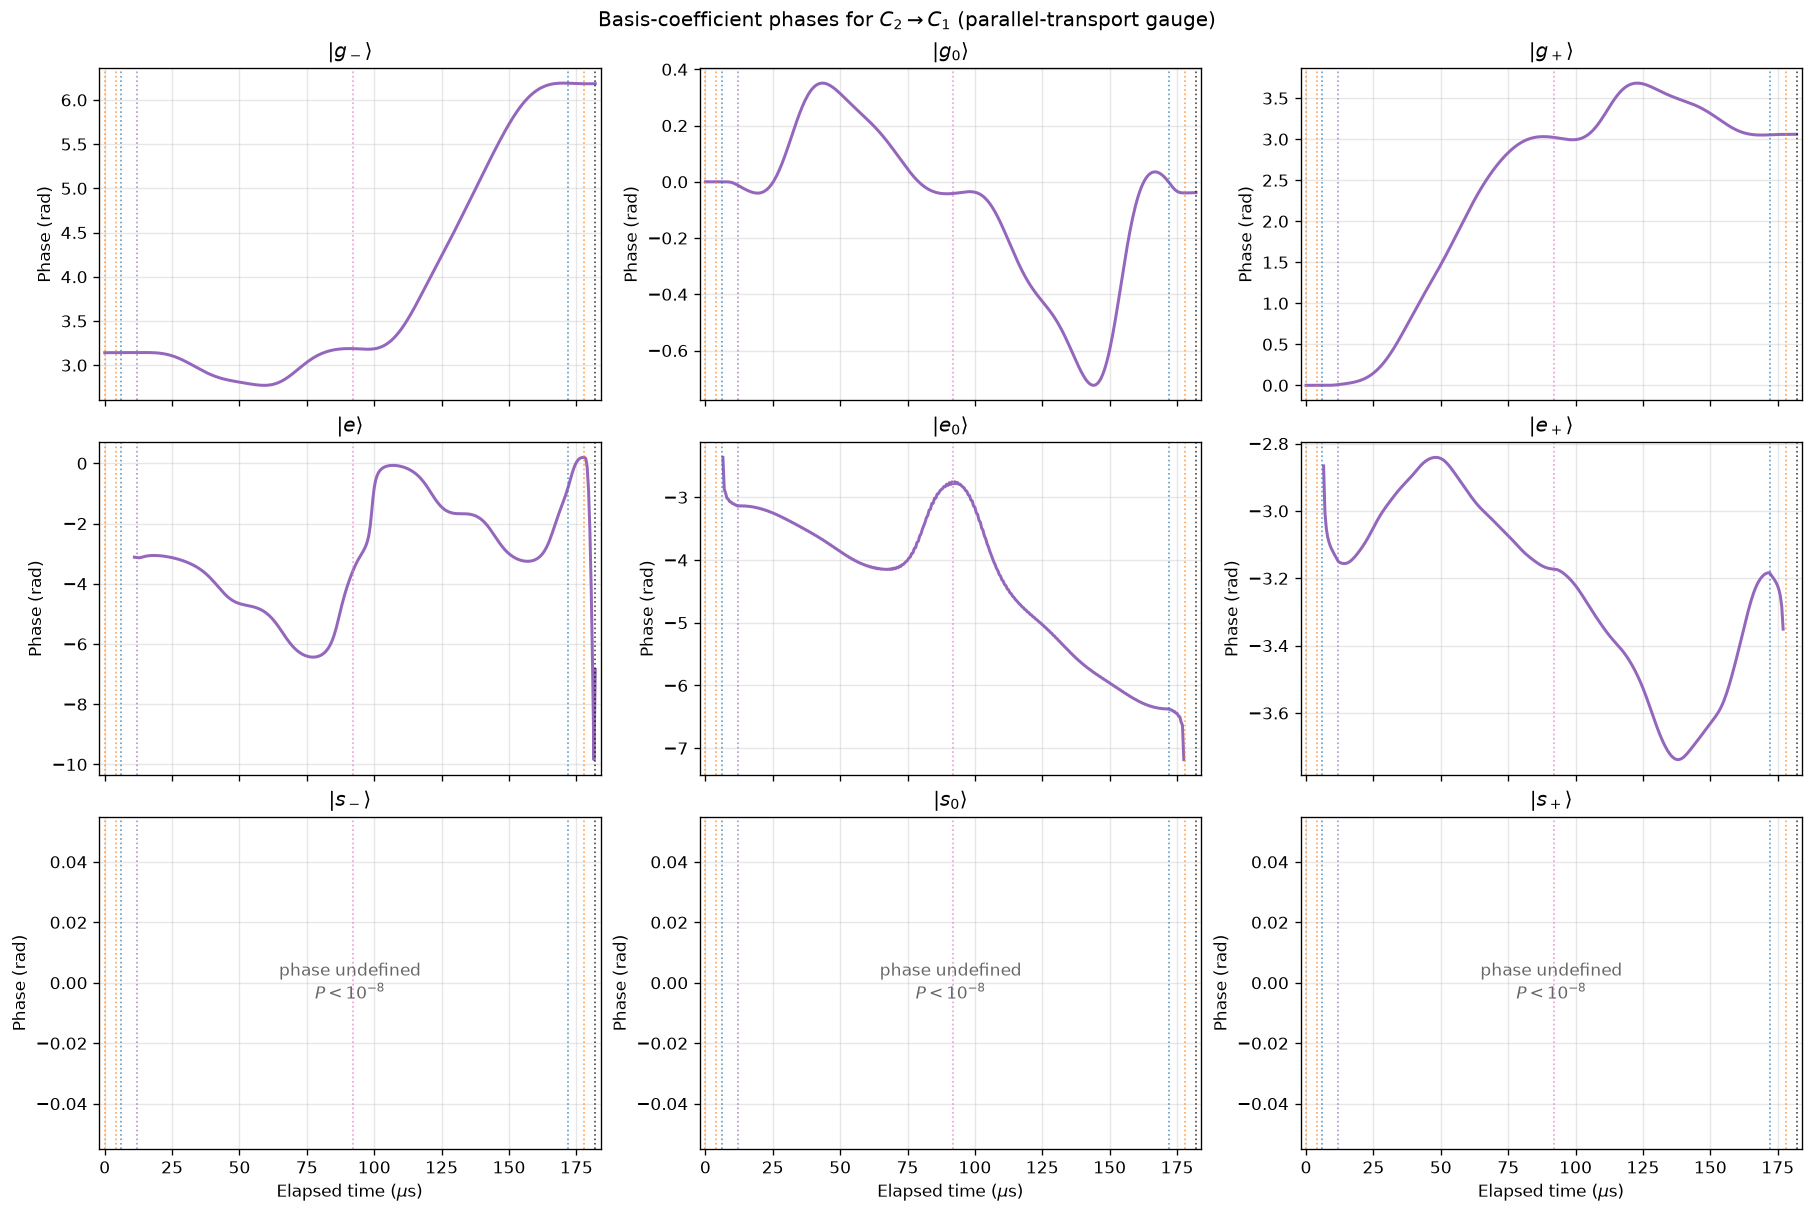

In [48]:
# =============================================================================
# 7.8 Plot the phase of every coefficient in a complete nine-state basis
# =============================================================================
# Order the untouched ms=+1 spectator eigenstates by their dominant product
# state so every coefficient has a stable, physically readable basis label.
plus_references = tuple(
    tensor(basis(3, 0), basis(3, nuclear_index))
    for nuclear_index in (2, 1, 0)
)
spectator_states, spectator_overlap = order_states_by_reference(
    plus_candidates,
    plus_references,
)

phase_basis_states = (
    *ground_states,
    *dressed_excited_states,
    *spectator_states,
)
phase_basis_labels = (
    r"$|g_-\rangle$",
    r"$|g_0\rangle$",
    r"$|g_+\rangle$",
    r"$|e\rangle$",
    r"$|e_0\rangle$",
    r"$|e_+\rangle$",
    r"$|s_-\rangle$",
    r"$|s_0\rangle$",
    r"$|s_+\rangle$",
)
phase_visibility_population = 1e-8


def fix_parallel_transport_gauge(states):
    """Remove arbitrary step-to-step global phase from a ket trajectory.

    Parameters
    ----------
    states : sequence of qutip.Qobj
        Consecutive normalized ket states returned by the PulsedSim solver.

    Returns
    -------
    tuple of qutip.Qobj
        Gauge-fixed kets. Every ket is phase-aligned so its overlap with the
        preceding ket is real and nonnegative. Relative component phases are
        unchanged and are therefore suitable for plotting.
    """
    gauge_fixed = [states[0].copy()]
    for state in states[1:]:
        overlap_with_previous = gauge_fixed[-1].overlap(state)
        if abs(overlap_with_previous) > 1e-14:
            state = state * np.exp(-1j * np.angle(overlap_with_previous))
        gauge_fixed.append(state.copy())
    return tuple(gauge_fixed)


def visible_unwrapped_phase(complex_coefficients, population_threshold=1e-8):
    """Unwrap coefficient phase only where that basis state is populated.

    Parameters
    ----------
    complex_coefficients : numpy.ndarray
        One complex basis coefficient at every stored time.
    population_threshold : float
        Minimum coefficient population for its phase to be meaningful.

    Returns
    -------
    numpy.ndarray
        Unwrapped phase in radians, with NaN where the coefficient magnitude is
        too small to define a numerically or physically meaningful phase.
    """
    coefficients = np.asarray(complex_coefficients, dtype=complex)
    visible = np.abs(coefficients)**2 >= population_threshold
    phase = np.full(coefficients.shape, np.nan, dtype=float)
    visible_indices = np.flatnonzero(visible)
    if len(visible_indices) == 0:
        return phase
    run_boundaries = np.flatnonzero(np.diff(visible_indices) > 1) + 1
    for index_run in np.split(visible_indices, run_boundaries):
        phase[index_run] = np.unwrap(np.angle(coefficients[index_run]))
    return phase


phase_basis_overlap = np.array([
    [state_a.overlap(state_b) for state_b in phase_basis_states]
    for state_a in phase_basis_states
])
assert np.allclose(phase_basis_overlap, np.eye(9), atol=1e-10)

for result, title in (
    (loop_result_C2C1, r"Basis-coefficient phases for $C_1\rightarrow C_2$"),
    (loop_result_C1C2, r"Basis-coefficient phases for $C_2\rightarrow C_1$"),
):
    gauge_fixed_states = fix_parallel_transport_gauge(result["states"])
    coefficient_trajectory = np.array([
        [basis_state.overlap(state) for basis_state in phase_basis_states]
        for state in gauge_fixed_states
    ])
    coefficient_phases = np.column_stack([
        visible_unwrapped_phase(
            coefficient_trajectory[:, basis_index],
            phase_visibility_population,
        )
        for basis_index in range(9)
    ])

    fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, constrained_layout=True)
    for basis_index, (ax, basis_label) in enumerate(zip(axes.flat, phase_basis_labels)):
        phase_curve = coefficient_phases[:, basis_index]
        ax.plot(
            result["times_us"],
            phase_curve,
            color="tab:purple",
            lw=1.8,
        )
        mark_loop_sequence_events(ax, result["order"], annotate=False)
        ax.set(
            xlim=(-2.0, loop_sequence_duration_us + 2.0),
            ylabel="Phase (rad)",
            title=basis_label,
        )
        if np.all(np.isnan(phase_curve)):
            ax.text(
                0.5,
                0.5,
                "phase undefined\n" + r"$P<10^{-8}$",
                ha="center",
                va="center",
                transform=ax.transAxes,
                color="0.4",
            )
    for ax in axes[-1]:
        ax.set_xlabel(r"Elapsed time ($\mu$s)")
    fig.suptitle(title + " (parallel-transport gauge)")
    plt.show()

    result["phase_basis_labels"] = phase_basis_labels
    result["basis_coefficients"] = coefficient_trajectory
    result["basis_phases_rad"] = coefficient_phases

#### Reading the basis-vector phase plots

**How the plots were generated.** The complete nine-state basis contains the three logical ground states, all three RF-dressed $m_s=-1$ states, and the three retained $m_s=+1$ spectator states. At every stored PulsedSim time, the code evaluates the complex coefficient $a_j(t)=\langle j|\psi(t)\rangle$ and plots $\arg a_j(t)$ in its own subplot. Adjacent evolved kets are placed in a parallel-transport gauge so arbitrary solver-wide global phase does not obscure the physically relevant relative phases.

**Why some phase traces disappear.** A phase is undefined when its coefficient is zero. The code therefore masks a phase whenever $|a_j|^2<10^{-8}$. In particular, the $m_s=+1$ spectator panels should remain blank because the rotating-frame RF and MW control model does not couple into that manifold. A blank panel is evidence of zero population, not missing simulation data.

**Physical intuition.** Population plots show where the quantum state is, whereas coefficient phases show how occupied basis components interfere. The separate phase trajectories make the order dependence more explicit: changing MW$_-$ first and MW$_+$ second does not generally produce the same relative phases as the reversed sequence. Only relative phases and final interference are observable; an overall ket phase is not.